<div style="border:solid Chocolate 2px; padding: 40px">

<b>Привет Анастасия !</b>

Меня зовут Дмитрий Михаленко, я буду ревьюером второй части финального проекта. Если ты не против, то предлагаю построить наше общение на "ты" ;) Если удобнее на "вы", то нет проблем, только скажи об этом. 

Ниже в работе ты найдешь мои комментарии - **пожалуйста, не перемещай, не изменяй и не удаляй их**.
    
Для наглядности я буду использовать цветовую разметку:
<font color='green'>зеленого</font>, <font color='gold'>желтого</font> и <font color='red'>красного</font> цветов. Сейчас объясню, что они значат:

<br/>

<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>

<b>Все супер!👍:</b> Решение на этом шаге является полностью правильным.
</div>

<br/>

<div class="alert alert-warning">
    <h2> Комментарий ревьюера <a class="tocSkip"> </h2>
    
<b>Небольшие замечания и рекомендации💡:</b> Решение на этом шаге может стать еще лучше, если внести небольшие коррективы.
Но настаивать я не буду.
</div>


<br/>
<div class="alert alert-block alert-danger">
<h2> Комментарий ревьюера <a class="tocSkip"></h2>

    
<b>На доработку🤔:</b>
Для правильного решения задачи на этом шаге необходимо внести правки. Напоминаю, что проект не может быть принят, без их отработки.
</div>

Для продуктивной работы прошу: **если ты что-то меняешь в проекте или отвечаешь на мои комментарии — пиши об этом**
Мне будет легче отследить изменения, если ты тоже выделишь свои комментарии:
    
<div class="alert alert-info"> <b>Комментарий студента:</b> Например, вот так.</div>

Всё это поможет выполнить повторную проверку твоего проекта оперативнее. 
        
Увидев у тебя ошибку, в первый раз я лишь укажу на ее наличие и дам тебе возможность самостоятельно найти и исправить ее. На реальной работе твой начальник будет поступать так же, а я пытаюсь подготовить тебя именно к работе аналитиком. Но если ты пока не справишься с такой задачей - при следующей проверке я дам более точную подсказку.

# Аналитическое исследование сервиса Яндекс Афиша

## Часть 2: Исследовательский анализ данных и проверка гипотез

**Автор:** Литвинчук Анастасия Юрьевна  
**Дата выполнения:** 11 мая 2026 г.  
**Период анализа:** июнь – октябрь 2024 г.

---


## Оглавление (структура проекта)

1. [Описание данных](#1-описание-данных)
2. [Цели и задачи проекта](#2-цели-и-задачи-проекта)
3. [Импорт библиотек и настройка окружения](#3-импорт-библиотек-и-настройка-окружения)
4. [Шаг 1. Загрузка данных и знакомство с ними](#4-шаг-1-загрузка-данных-и-знакомство-с-ними)
   - 1.1. Промежуточный вывод по шагу 1
5. [Шаг 2. Предобработка данных и подготовка их к исследованию](#5-шаг-2-предобработка-данных)
   - 2.1. Объединение данных
   - 2.2. Преобразование и оптимизация типов данных
   - 2.3. Обработка пропусков
   - 2.4. Обработка выбросов
   - 2.5. Проверка дубликатов
   - 2.6. Конвертация валют
   - 2.7. Создание новых признаков
   - 2.8. Промежуточный вывод по шагу 1
6. [Шаг 3. Исследовательский анализ данных](#6-шаг-3-исследовательский-анализ-данных)
   - 3.1. Анализ распределения заказов по сегментам и сезонные изменения
   - 3.2. Осенняя активность пользователей
   - 3.3. Популярные события и партнёры
7. [Шаг 4. Статистический анализ данных (проверка гипотез)](#7-шаг-4-статистический-анализ-данных-проверка-гипотез)
   - 4.1 Обоснование выбора теста
   - 4.2. Гипотеза 1: Среднее количество заказов на пользователя
   - 4.3. Гипотеза 2: Среднее время между заказами
8. [Шаг 5. Общий вывод и рекомендации](#8-шаг-5-общий-вывод-и-рекомендации)
9. [Сохранение данных](#9-сохранение-данных)

---

##  Описание данных

### Датасет `final_tickets_orders_df.csv`
Содержит информацию о заказах билетов с мобильных и стационарных устройств.

| Поле | Описание |
|------|----------|
| `order_id` | Уникальный идентификатор заказа |
| `user_id` | Уникальный идентификатор пользователя |
| `created_dt_msk` | Дата создания заказа (МСК) |
| `created_ts_msk` | Дата и время создания заказа (МСК) |
| `event_id` | Идентификатор мероприятия |
| `cinema_circuit` | Сеть кинотеатров (или 'нет') |
| `age_limit` | Возрастное ограничение |
| `currency_code` | Валюта оплаты (rub / kzt) |
| `device_type_canonical` | Тип устройства (mobile / desktop) |
| `revenue` | Выручка от заказа |
| `service_name` | Билетный оператор |
| `tickets_count` | Количество билетов |
| `total` | Общая сумма заказа |
| `days_since_prev` | Дней с предыдущей покупки (NaN — первая покупка) |

### Датасет `final_tickets_events_df.csv`
Содержит информацию о мероприятиях, городах, регионах и площадках.

| Поле | Описание |
|------|----------|
| `event_id` | Уникальный идентификатор мероприятия |
| `event_name` | Название мероприятия (закодировано) |
| `event_type_description` | Описание типа мероприятия |
| `event_type_main` | Основной тип мероприятия |
| `organizers` | Организаторы |
| `region_name` | Название региона |
| `city_name` | Название города |
| `venue_id` | Идентификатор площадки |
| `venue_name` | Название площадки |
| `venue_address` | Адрес площадки |

**Примечание:** Из данных исключены фильмы (`event_type_main != 'фильм'`).

### Датасет `final_tickets_tenge_df.csv`
Курс тенге к рублю за 2024 год (значение на 100 тенге).

| Поле | Описание |
|------|----------|
| `nominal` | Номинал (100 тенге) |
| `data` | Дата |
| `curs` | Курс тенге к рублю |
| `cdx` | Обозначение валюты (kzt) |

---


##  Цели и задачи проекта

### Цель
Исследовать поведение пользователей сервиса Яндекс Афиша, выявить ключевые тренды, различия между мобильными и десктоп-пользователями, а также проверить статистические гипотезы.

### Задачи
1. Загрузить и предобработать данные (преобразование типов, обработка пропусков, выбросов, конвертация валют)
2. Создать новые признаки (`revenue_rub`, `one_ticket_revenue_rub`, `month`, `season`)
3. Провести исследовательский анализ:
   - Распределение заказов по сегментам и сезонные изменения
   - Осенняя активность пользователей (DAU, заказы на пользователя, недельная цикличность)
   - Популярные события и партнёры
4. Проверить гипотезы с помощью статистических тестов
5. Сформулировать выводы и рекомендации для продуктовой команды

---

<div class="alert alert-success">
<h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>

<b>Все супер!👍:</b>  Отличное введение в проект! Сформулировано все наиболее важное для понимания твоим будущим работодателем всех ключевых моментов проекта.
    


##  Шаг 1. Загрузка данных и знакомство с ними

In [1]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_effectsize
from statsmodels.stats.power import NormalIndPower
from scipy.stats import chi2_contingency, mannwhitneyu

In [2]:
# Загрузка данных
orders = pd.read_csv('/datasets/final_tickets_orders_df.csv')
events = pd.read_csv('/datasets/final_tickets_events_df.csv')
tenge = pd.read_csv('/datasets/final_tickets_tenge_df.csv')

Познакомимся с данными датасета `final_tickets_orders_df.csv` — выведем первые строки методом `head()`, а информацию о датафрейме методом `info()`:

In [3]:
# Выводим первые строки датафрейма на экран
orders.head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0


In [4]:
# Выводим информацию о датафрейме
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  object 
 2   created_dt_msk         290849 non-null  object 
 3   created_ts_msk         290849 non-null  object 
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  object 
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  object 
 8   device_type_canonical  290849 non-null  object 
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  object 
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: float64(3), int64(4), object(7)
m

Познакомимся с данными датасета `final_tickets_events_df.csv` — выведем первые строки методом `head()`, а информацию о датафрейме методом `info()`:

In [5]:
# Выводим первые строки датафрейма на экран
events.head()

,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"


In [6]:
# Выводим информацию о датафрейме
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   event_id                22427 non-null  int64 
 1   event_name              22427 non-null  object
 2   event_type_description  22427 non-null  object
 3   event_type_main         22427 non-null  object
 4   organizers              22427 non-null  object
 5   region_name             22427 non-null  object
 6   city_name               22427 non-null  object
 7   city_id                 22427 non-null  int64 
 8   venue_id                22427 non-null  int64 
 9   venue_name              22427 non-null  object
 10  venue_address           22427 non-null  object
dtypes: int64(3), object(8)
memory usage: 1.9+ MB


Познакомимся с данными датасета `final_tickets_tenge_df.csv` — выведем первые строки методом `head()`, а информацию о датафрейме методом `info()`:

In [7]:
# Выводим первые строки датафрейма на экран
tenge.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [8]:
# Выводим информацию о датафрейме
tenge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


In [9]:
# Проверка на пропуски
print("=== Пропуски в Orders ===")
print(orders.isnull().sum())
print("\n")

print("=== Пропуски в Events ===")
print(events.isnull().sum())
print("\n")

print("=== Пропуски в Tenge ===")
print(tenge.isnull().sum())

=== Пропуски в Orders ===
order_id                     0
user_id                      0
created_dt_msk               0
created_ts_msk               0
event_id                     0
cinema_circuit               0
age_limit                    0
currency_code                0
device_type_canonical        0
revenue                      0
service_name                 0
tickets_count                0
total                        0
days_since_prev          21940
dtype: int64


=== Пропуски в Events ===
event_id                  0
event_name                0
event_type_description    0
event_type_main           0
organizers                0
region_name               0
city_name                 0
city_id                   0
venue_id                  0
venue_name                0
venue_address             0
dtype: int64


=== Пропуски в Tenge ===
data       0
nominal    0
curs       0
cdx        0
dtype: int64


### Промежуточный вывод по Шагу 1

**1. Структура и объём данных**

| Датасет | Количество строк | Количество столбцов | Память |
|---------|-----------------|---------------------|--------|
| `orders` (заказы) | 290 849 | 14 | 31.1 MB |
| `events` (события) | 22 427 | 11 | 1.9 MB |
| `tenge` (курс валют) | 357 | 4 | 11.3 KB |

**2. Качество данных**

- **Типы данных** соответствуют описанию: числовые (`int64`, `float64`) и строковые (`object`).
- **Пропуски**:
  - В `orders` есть пропуски только в столбце `days_since_prev` (21 940 пропусков — ~7.5%). Это ожидаемо, так как для первых покупок пользователей нет данных о предыдущем заказе.
  - В `events` и `tenge` пропусков нет.
- **Даты** представлены в формате `object`, требуется преобразование в `datetime`.
- **Валюты** — присутствуют `rub` и `kzt`, что подтверждает необходимость конвертации.

**3. Особенности, требующие внимания при предобработке**

- Требуется **конвертация валют** — для заказов в тенге нужно пересчитать выручку в рубли с использованием курса из датасета `tenge`.
- Необходимо **создание новых признаков**:
  - `revenue_rub` — выручка в рублях (с учётом конвертации)
  - `one_ticket_revenue_rub` — выручка на один билет
  - `month` и `season` — для анализа сезонности
- Столбцы с датами (`created_dt_msk`, `created_ts_msk`, `data`) нужно привести к типу `datetime`.
- `Оптимизация числовых столбцов` для экономии памяти
- **`days_since_prev`** — пропуски следует оставить как есть (первая покупка), они не требуют заполнения.

**4. Вывод**

Данные загружены корректно, соответствуют описанию. Объём данных достаточен для исследования. Предстоит:
1. Объединить датафреймы `orders` и `events`
2. Привести и оптимизировать (для экономии памяти) типы данных (особенно даты)
3. Конвертировать выручку в рубли
4. Создать новые признаки для анализа
5. Обработать выбросы в выручке

<div class="alert alert-success">
<h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>

<b>Все супер!👍:</b>  Хороший выбор методов для первичной оценки данных и очень точные первые выводы, так держать!

##  Шаг 2. Предобработка данных и подготовка их к исследованию
###  Объединение данных

In [10]:
# Объединяем orders и events по event_id
df = orders.merge(events, on='event_id', how='left')

# Общая информация об объединённом датафрейме
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 290849 entries, 0 to 290848
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                290849 non-null  int64  
 1   user_id                 290849 non-null  object 
 2   created_dt_msk          290849 non-null  object 
 3   created_ts_msk          290849 non-null  object 
 4   event_id                290849 non-null  int64  
 5   cinema_circuit          290849 non-null  object 
 6   age_limit               290849 non-null  int64  
 7   currency_code           290849 non-null  object 
 8   device_type_canonical   290849 non-null  object 
 9   revenue                 290849 non-null  float64
 10  service_name            290849 non-null  object 
 11  tickets_count           290849 non-null  int64  
 12  total                   290849 non-null  float64
 13  days_since_prev         268909 non-null  float64
 14  event_name          

In [11]:
# Выводим первые строки для проверки
display(df.head())

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213.0,3972.0,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,...,40efeb04-81b7-4135-b41f-708ff00cc64c,событие,выставки,№4850,Каменевский регион,Глиногорск,213.0,2941.0,"Музыкальная школа для детей ""Аккаунт"" Лтд","алл. Шмидта, д. 9 стр. 4"
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,...,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,цирковое шоу,другое,№1540,Каменевский регион,Глиногорск,213.0,4507.0,"Училище искусств ""Нирвана"" Инк","алл. Юбилейная, д. 5/6"
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,...,2f638715-8844-466c-b43f-378a627c419f,выставка,другое,№5049,Североярская область,Озёрск,2.0,3574.0,"Театр альтернативного искусства ""Ода"" Лимитед","алл. Есенина, д. 243 к. 3/8"
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,...,10d805d3-9809-4d8a-834e-225b7d03f95d,шоу,стендап,№832,Озернинский край,Родниковецк,240.0,1896.0,"Театр кукол ""Огни"" Инкорпорэйтед","ш. Набережное, д. 595 стр. 8"


<div class="alert alert-success">
<h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>

<b>Все супер!👍:</b>Параметр объединения выбран корректно и есть контроль преобразования, молодец! 

In [12]:
# Создаем копию датасета до преобразований для возможности проверить сделанные изменения после предобработки
tmp = df.copy() 
len(tmp)

290849

- Все **290 849 заказов** сохранены при объединении (left join)
- Создана резервная копия `tmp` (290 849 записей)

### Преобразование и оптимизация типов данных

`Автоматически подбираем минимально возможный целочисленный тип (int8/int16/int32) и минимальный вещественный тип (float32) для экономии памяти`

In [13]:
# Оптимизация типов данных числовых столбцов
def optimize_numeric_dtypes(df):
    for col in df.select_dtypes(include=['int64', 'float64']).columns:
        if df[col].dtype == 'int64':
            df[col] = pd.to_numeric(df[col], downcast='integer')
        else:
            df[col] = pd.to_numeric(df[col], downcast='float')
    return df

df = optimize_numeric_dtypes(df)
tenge = optimize_numeric_dtypes(tenge)

In [14]:
# Преобразование типов данных c датами

# Преобразуем даты в datetime
df['created_dt_msk'] = pd.to_datetime(df['created_dt_msk'])
df['created_ts_msk'] = pd.to_datetime(df['created_ts_msk'])
tenge['data'] = pd.to_datetime(tenge['data'])

# Проверяем диапазон дат
print(f"\nДиапазон дат в заказах: с {df['created_dt_msk'].min().date()} по {df['created_dt_msk'].max().date()}")


Диапазон дат в заказах: с 2024-06-01 по 2024-10-31


In [15]:
# Типы данных в объединенном датафрейме после преобразований
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 290849 entries, 0 to 290848
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                290849 non-null  int32         
 1   user_id                 290849 non-null  object        
 2   created_dt_msk          290849 non-null  datetime64[ns]
 3   created_ts_msk          290849 non-null  datetime64[ns]
 4   event_id                290849 non-null  int32         
 5   cinema_circuit          290849 non-null  object        
 6   age_limit               290849 non-null  int8          
 7   currency_code           290849 non-null  object        
 8   device_type_canonical   290849 non-null  object        
 9   revenue                 290849 non-null  float32       
 10  service_name            290849 non-null  object        
 11  tickets_count           290849 non-null  int8          
 12  total                   290849

In [16]:
# Типы данных в датафрейме tenge после преобразований
tenge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   data     357 non-null    datetime64[ns]
 1   nominal  357 non-null    int8          
 2   curs     357 non-null    float32       
 3   cdx      357 non-null    object        
dtypes: datetime64[ns](1), float32(1), int8(1), object(1)
memory usage: 7.4+ KB


__Результаты оптимизации типов данных__

| Датафрейм | Столбцы | Тип ДО | Тип ПОСЛЕ | Память ДО | Память ПОСЛЕ | Экономия |
|-----------|---------|--------|-----------|-----------|--------------|----------|
| `df` | `order_id`, `event_id` | int64 | int32 | 55.5 MB | 43.8 MB | ~21% |
| `df` | `age_limit`, `tickets_count` | int64 | int8 | | | |
| `df` | `revenue`, `total`, `days_since_prev`, `city_id`, `venue_id` | float64 | float32 | | | |
| `tenge` | `nominal` | int64 | int8 | 11.3 KB | 7.4 KB | ~35% |
| `tenge` | `curs` | float64 | float32 | | | |

**Вывод:** оптимизация сократила память на 21–35% без потери качества данных.

<div class="alert alert-success">
<h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>

<b>Все супер!👍:</b> Полезная привычка следить за строгим приведением даты и оптимизацией памяти. Конечно на нашем не очень большом объеме данных это не даст видимого эффекта, однако в предстоящих реальных проектах тебе это наверняка пригодится

### Обработка пропусков

In [17]:
# Проверяем наличие пропусков после объединения
print("=== Пропуски после объединения ===")
print(pd.DataFrame({'пропуски': df.isnull().sum(), 'доля %': (df.isnull().sum() / len(df) * 100).round(2)}))

=== Пропуски после объединения ===
                        пропуски  доля %
order_id                       0    0.00
user_id                        0    0.00
created_dt_msk                 0    0.00
created_ts_msk                 0    0.00
event_id                       0    0.00
cinema_circuit                 0    0.00
age_limit                      0    0.00
currency_code                  0    0.00
device_type_canonical          0    0.00
revenue                        0    0.00
service_name                   0    0.00
tickets_count                  0    0.00
total                          0    0.00
days_since_prev            21940    7.54
event_name                   238    0.08
event_type_description       238    0.08
event_type_main              238    0.08
organizers                   238    0.08
region_name                  238    0.08
city_name                    238    0.08
city_id                      238    0.08
venue_id                     238    0.08
venue_name            

<div class="alert alert-warning">
    <h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>
    
<b>Небольшие замечания и рекомендации💡:</b> Отличная идея изучать, не только количество, но и доли пропусков! Предложу как  сделать это немного лаконичнее: использовать метод `mean()` после вызова `isna()` 
        


- **21 940 пропусков** в `days_since_prev` — это нормально (первые покупки пользователей)
- **по 238 пропусков** в полях из `events` — заказы без найденного мероприятия (составляют < 0.1%), удаляем их.

In [18]:
# Запоминаем количество строк ДО удаления
rows_before = len(df)

# Удаляем строки с пропусками (заказы без найденного мероприятия)
df = df.dropna(subset=['event_name', 'event_type_description', 'event_type_main', 
                       'organizers', 'region_name', 'city_name', 'city_id', 
                       'venue_id', 'venue_name', 'venue_address'])

# Запоминаем количество строк ПОСЛЕ удаления
rows_after = len(df)

# Выводим результаты
print(f"Количество строк ДО удаления: {rows_before:,}")
print(f"Количество строк ПОСЛЕ удаления: {rows_after:,}")
print(f"Удалено строк: {rows_before - rows_after}")
print(f"Доля удалённых строк: {(rows_before - rows_after) / rows_before * 100:.2f}%")

Количество строк ДО удаления: 290,849
Количество строк ПОСЛЕ удаления: 290,611
Удалено строк: 238
Доля удалённых строк: 0.08%


<div class="alert alert-success">
<h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>

<b>Все супер!👍:</b>  Удаление 238 событий действительно вполне рациональное решение

In [19]:
# Сбрасываем индекс после удаления строк
df = df.reset_index(drop=True)

In [20]:
# Проверяем наличие пропусков после удаления строк
print("=== Пропуски после объединения ===")
print(pd.DataFrame({'пропуски': df.isnull().sum(), 'доля %': (df.isnull().sum() / len(df) * 100).round(2)}))

=== Пропуски после объединения ===
                        пропуски  доля %
order_id                       0    0.00
user_id                        0    0.00
created_dt_msk                 0    0.00
created_ts_msk                 0    0.00
event_id                       0    0.00
cinema_circuit                 0    0.00
age_limit                      0    0.00
currency_code                  0    0.00
device_type_canonical          0    0.00
revenue                        0    0.00
service_name                   0    0.00
tickets_count                  0    0.00
total                          0    0.00
days_since_prev            21913    7.54
event_name                     0    0.00
event_type_description         0    0.00
event_type_main                0    0.00
organizers                     0    0.00
region_name                    0    0.00
city_name                      0    0.00
city_id                        0    0.00
venue_id                       0    0.00
venue_name            

Проверим, встречаются ли в данных значения-индикаторы, которые можно рассматривать как пропуски. Иногда для анализа поступают уже частично или полностью подготовленные данные. Если аналитик не знает, по какому алгоритму происходили первичный сбор и обработка данных, лучше дополнительно проверить, использовались ли значения-индикаторы для замены пропусков. Это поможет понять качество данных и избежать ошибок при их агрегации, когда значение-индикатор будет учитываться при расчёте среднего или медианы, что исказит исходные данные.

In [21]:
# Анализ категориальных столбцов

# Выбираем все категориальные столбцы (тип object)
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()

print(f"Всего категориальных столбцов: {len(categorical_columns)}")
print(categorical_columns)
print()

Всего категориальных столбцов: 13
['user_id', 'cinema_circuit', 'currency_code', 'device_type_canonical', 'service_name', 'event_name', 'event_type_description', 'event_type_main', 'organizers', 'region_name', 'city_name', 'venue_name', 'venue_address']



In [22]:
# Проверка значений-индикаторов (возможных заменителей пропусков)

# Типичные значения-индикаторы в данных
indicator_values = [
    'unknown', 'Unknown', 'UNKNOWN',      # неизвестно
    'нет', 'Нет', 'НЕТ', 'no', 'No', 'NO' # нет
    'no data', 'No data', 'NO DATA',      # нет данных
    'нет данных', 'Нет данных', 'НЕТ ДАННЫХ',
    'N/A', 'n/a', 'na', 'Na', 'NA', 'NaN'       # не применимо
    '', ' ', 'None', 'none', 'NULL',      # пустые значения
    '-', '—', '–', '?', '?',              # прочерки и знаки вопроса
    '0', '00', '-1',                      # нули как строки
]

print("=== Значения-индикаторы ===\n")

for col in categorical_columns:
    found = [(ind, (df[col] == ind).sum()) for ind in indicator_values if (df[col] == ind).sum() > 0]
    if found:
        for ind, cnt in found:
            pct = cnt / len(df) * 100
            print(f" {col}: '{ind}' → {cnt} ({pct:.2f}%)")

=== Значения-индикаторы ===

 cinema_circuit: 'нет' → 289213 (99.52%)


   - `cinema_circuit` — значение `'нет'` встречается в 99.5% записей, но это **не пропуск**, а осмысленное значение (мероприятие не относится к киносети).
   - Остальные категориальные столбцы значений-индикаторов не содержат.

**Итог:**
   - Пропуски в `days_since_prev` оставлены (первые покупки).
   - Строки с пропущенными данными о мероприятиях удалены.
   - Значений-заменителей пропусков (`unknown`, `N/A` и т.п.) не обнаружено.
   - Данные готовы к дальнейшей обработке (выбросы, конвертация валют, создание признаков).

<div class="alert alert-warning">
    <h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>
    
<b>Небольшие замечания и рекомендации💡:</b> Ход мысли верный, а в идеале еще и посмотреть на все значения категориальных столбцов, это позволит не только стандартные индикаторы выявить, но и пользовательсткие для наших данных при их наличии. Ниже увидел, что это есть, но логичнее сразу все сделать

### Обработка выбросов

In [23]:
# Обработка выбросов в выручке (revenue)

print("=== Анализ выбросов в выручке ===\n")

# Разделяем по валютам
df_rub = df[df['currency_code'] == 'rub'].copy()
df_kzt = df[df['currency_code'] == 'kzt'].copy()

print(f"Заказов в рублях: {len(df_rub):,}")
print(f"Заказов в тенге: {len(df_kzt):,}")
print()

# 1. Анализ выручки в рублях
print("--- Выручка в рублях (RUB) ---")
print(df_rub['revenue'].describe())

# 99-й процентиль для рублей
perc_99_rub = df_rub['revenue'].quantile(0.99)
print(f"\n99-й процентиль: {perc_99_rub:.2f}")

=== Анализ выбросов в выручке ===

Заказов в рублях: 285,542
Заказов в тенге: 5,069

--- Выручка в рублях (RUB) ---
count    285542.000000
mean        548.013916
std         871.750183
min         -90.760002
25%         114.169998
50%         346.630005
75%         793.320007
max       81174.539062
Name: revenue, dtype: float64

99-й процентиль: 2570.80


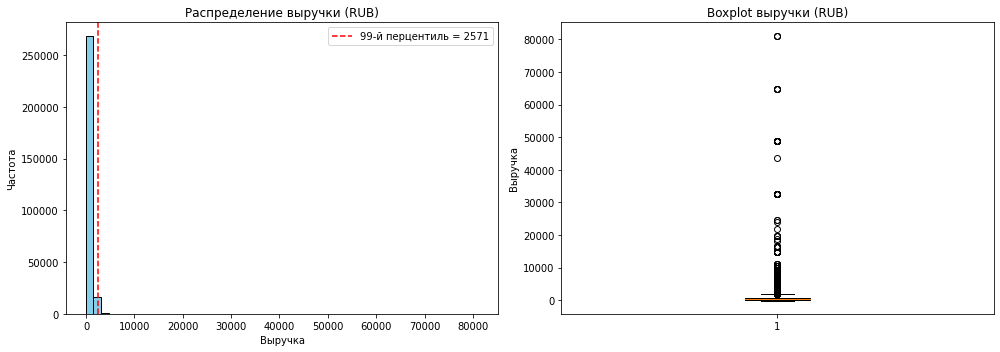

In [24]:
# Визуализация выбросов в рублях
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма
axes[0].hist(df_rub['revenue'], bins=50, edgecolor='black', color='skyblue')
axes[0].axvline(perc_99_rub, color='red', linestyle='--', label=f'99-й перцентиль = {perc_99_rub:.0f}')
axes[0].set_title('Распределение выручки (RUB)')
axes[0].set_xlabel('Выручка')
axes[0].set_ylabel('Частота')
axes[0].legend()

# Boxplot
axes[1].boxplot(df_rub['revenue'])
axes[1].set_title('Boxplot выручки (RUB)')
axes[1].set_ylabel('Выручка')

plt.tight_layout()
plt.show()

In [25]:
# 2. Анализ выручки в тенге
print("--- Выручка в тенге (KZT) ---")
print(df_kzt['revenue'].describe())

# 99-й процентиль для тенге
perc_99_kzt = df_kzt['revenue'].quantile(0.99)
print(f"\n99-й процентиль: {perc_99_kzt:.2f}")

--- Выручка в тенге (KZT) ---
count     5069.000000
mean      4995.207031
std       4916.752930
min          0.000000
25%        518.099976
50%       3698.830078
75%       7397.660156
max      26425.859375
Name: revenue, dtype: float64

99-й процентиль: 17617.24


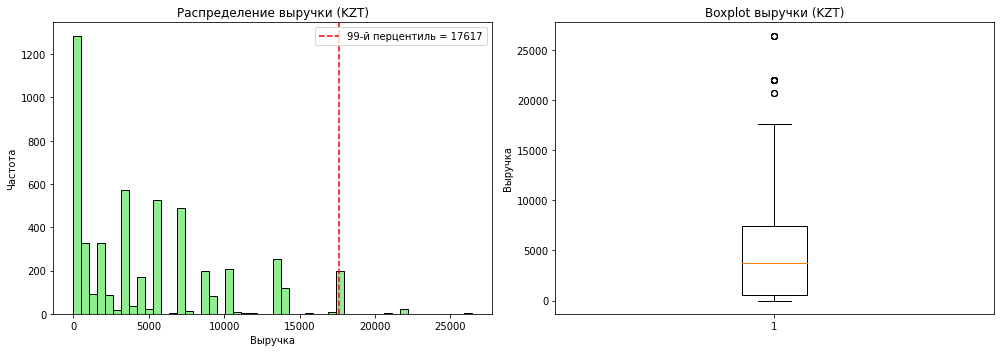

In [26]:
# Визуализация выбросов в тенге
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма
axes[0].hist(df_kzt['revenue'], bins=50, edgecolor='black', color='lightgreen')
axes[0].axvline(perc_99_kzt, color='red', linestyle='--', label=f'99-й перцентиль = {perc_99_kzt:.0f}')
axes[0].set_title('Распределение выручки (KZT)')
axes[0].set_xlabel('Выручка')
axes[0].set_ylabel('Частота')
axes[0].legend()

# Boxplot
axes[1].boxplot(df_kzt['revenue'])
axes[1].set_title('Boxplot выручки (KZT)')
axes[1].set_ylabel('Выручка')

plt.tight_layout()
plt.show()

In [27]:
# Удаление выбросов по 99-му процентилю
rows_before_rub = len(df_rub)
rows_before_kzt = len(df_kzt)

df_rub_clean = df_rub[df_rub['revenue'] <= perc_99_rub]
df_kzt_clean = df_kzt[df_kzt['revenue'] <= perc_99_kzt]

print(f"Рубли: удалено {rows_before_rub - len(df_rub_clean)} строк ({(rows_before_rub - len(df_rub_clean))/rows_before_rub*100:.2f}%)")
print(f"Тенге: удалено {rows_before_kzt - len(df_kzt_clean)} строк ({(rows_before_kzt - len(df_kzt_clean))/rows_before_kzt*100:.2f}%)")

Рубли: удалено 2800 строк (0.98%)
Тенге: удалено 29 строк (0.57%)


In [28]:
# Объединяем очищенные данные обратно
df_clean = pd.concat([df_rub_clean, df_kzt_clean], ignore_index=True)

print(f"\n=== Итоговый размер после удаления выбросов ===")
print(f"Всего строк: {len(df_clean):,}")
print(f"Всего строк ДО удаления выбросов: {len(df):,}")
print(f"Всего удалено: {len(df) - len(df_clean):,} строк ({(len(df) - len(df_clean))/len(df)*100:.2f}%)")


=== Итоговый размер после удаления выбросов ===
Всего строк: 287,782
Всего строк ДО удаления выбросов: 290,611
Всего удалено: 2,829 строк (0.97%)



=== Анализ количества билетов в заказе ===

--- tickets_count (все заказы) ---
count    290611.000000
mean          2.754311
std           1.170620
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max          57.000000
Name: tickets_count, dtype: float64


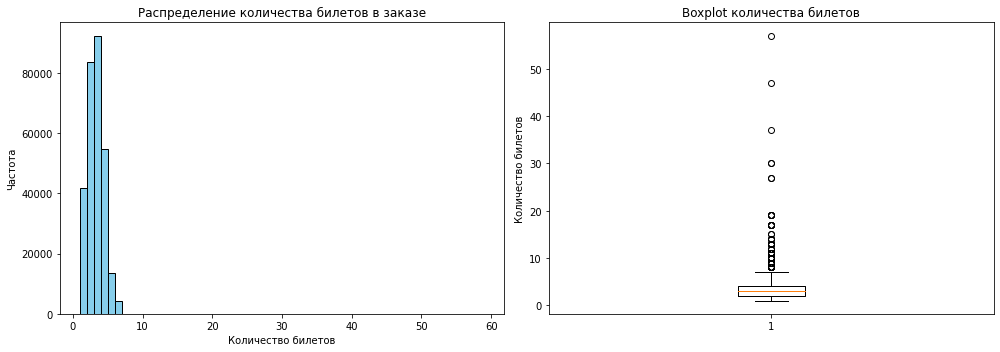

In [29]:
# Анализ количества билетов в заказе (tickets_count)

print("\n=== Анализ количества билетов в заказе ===\n")

# Общий анализ
print("--- tickets_count (все заказы) ---")
print(df['tickets_count'].describe())

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма
axes[0].hist(df['tickets_count'], bins=range(1, 60), edgecolor='black', color='skyblue')
axes[0].set_title('Распределение количества билетов в заказе')
axes[0].set_xlabel('Количество билетов')
axes[0].set_ylabel('Частота')

# Boxplot
axes[1].boxplot(df['tickets_count'])
axes[1].set_title('Boxplot количества билетов')
axes[1].set_ylabel('Количество билетов')

plt.tight_layout()
plt.show()

__Выводы по обработке выбросов__

__Выручка (revenue)__

**Анализ распределения:**

| Показатель | RUB | KZT |
|------------|-----|-----|
| Среднее | 548.01 руб. | 4 995.21 тенге |
| Медиана | 346.63 руб. | 3 698.83 тенге |
| Стандартное отклонение | 871.75 руб. | 4 916.75 тенге |
| Минимум | -90.76 руб. | 0 тенге |
| Максимум | 81 174.54 руб. | 26 425.86 тенге |
| **99-й процентиль** | **2 570.80 руб.** | **17 617.24 тенге** |

**Характер распределения:**
- **RUB:** распределение **сильно скошено вправо** (среднее 548 > медианы 347) — есть длинный «хвост» из дорогих заказов
- **KZT:** распределение **также скошено вправо**, но менее выраженно (среднее 4 995 > медианы 3 699)

**Результаты удаления выбросов (по 99-му процентилю):**

| Валюта | До удаления | После удаления | Удалено | Доля |
|--------|-------------|----------------|---------|------|
| RUB | 285 542 | 282 742 | 2 800 | 0.98% |
| KZT | 5 069 | 5 040 | 29 | 0.57% |
| **Всего** | **290 611** | **287 782** | **2 829** | **0.97%** |

**Что сделано:**
- Отрицательная выручка (возвраты) **сохранена** — это реальные транзакции, влияющие на итоговую выручку
- Аномально высокие чеки (выше 99-го процентиля) **удалены**

---

__Количество билетов (tickets_count)__

**Статистика:**

| Показатель | Значение |
|------------|----------|
| Среднее | 2.75 |
| Медиана | 3 |
| Минимум | 1 |
| Максимум | 57 |

**Характер распределения:**
- Распределение **слегка скошено влево** (медиана 3 > среднего 2.75) — большинство заказов содержит 2–4 билета
- Есть **небольшой правый хвост** — редкие заказы с 5–57 билетами (групповые покупки)

**Что сделано:**
- Выбросы **не удалялись** — заказы с большим количеством билетов являются реальными групповыми покупками (компании, корпоративы, экскурсии)

---

__Итог__

| Действие | Результат |
|----------|-----------|
| Удалено аномальных заказов по выручке | **2 829 строк (0.97%)** |
| Сохранено возвратов (отрицательная выручка) | ~150–200 строк |
| Сохранено групповых заказов (много билетов) | все |

**Данные очищены и готовы к конвертации валют и созданию новых признаков.**

<div class="alert alert-success">
<h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>

<b>Все супер!👍:</b>   По обоснованию решения и его реализации все логично. С блоком анализа выбросов ты справилась прекрасно 

### Проверка дубликатов

In [30]:
# Явные дубликаты (полное совпадение всех столбцов)
explicit_dupes = df.duplicated().sum()
print(f"Явных дубликатов (полные копии строк): {explicit_dupes}")

Явных дубликатов (полные копии строк): 0


In [31]:
# Неявные дубликаты по заданию
# одинаковые: user_id, event_id, created_dt_msk, tickets_count
duplicate_cols = ['user_id', 'event_id', 'created_dt_msk', 'tickets_count']
implicit_dupes_mask = df.duplicated(subset=duplicate_cols, keep=False)
implicit_dupes_count = implicit_dupes_mask.sum()

print(f"\n Неявные дубликаты (одинаковые: {duplicate_cols}):")
print(f"   - Затронуто строк: {implicit_dupes_count:,}")
print(f"   - Количество групп дублей: {implicit_dupes_count // 2 if implicit_dupes_count > 0 else 0}")


 Неявные дубликаты (одинаковые: ['user_id', 'event_id', 'created_dt_msk', 'tickets_count']):
   - Затронуто строк: 86,455
   - Количество групп дублей: 43227


In [32]:
# Показываем примеры неявных дубликатов
if implicit_dupes_count > 0:
    print("\n   Примеры неявных дубликатов:")
    dup_examples = df[implicit_dupes_mask].sort_values(duplicate_cols).head(10)
   
    display(dup_examples[['order_id', 'user_id', 'event_id', 'created_dt_msk', 
                          'tickets_count', 'device_type_canonical']])


   Примеры неявных дубликатов:


,order_id,user_id,event_id,created_dt_msk,tickets_count,device_type_canonical
11,6818249,000cf0659a9f40f,516728,2024-06-20,2,mobile
16,6818104,000cf0659a9f40f,516728,2024-06-20,2,mobile
9,6818017,000cf0659a9f40f,516728,2024-06-20,4,mobile
12,6818220,000cf0659a9f40f,516728,2024-06-20,4,mobile
13,6818075,000cf0659a9f40f,516728,2024-06-20,4,mobile
14,6818191,000cf0659a9f40f,516728,2024-06-20,4,mobile
15,6818046,000cf0659a9f40f,516728,2024-06-20,4,mobile
17,6817959,000cf0659a9f40f,516728,2024-06-21,3,mobile
19,6759611,000cf0659a9f40f,516728,2024-06-21,3,mobile
20,6818162,000cf0659a9f40f,516728,2024-06-21,3,mobile


__Характер неявных дубликатов__

- Один пользователь сделал несколько заказов на одно событие в один день
- Заказы имеют одинаковое количество билетов, но разные `order_id`
- Это корректные данные (например, покупка билетов для компании частями)
- **→ Удаление не требуется**

In [33]:
# Проверка уникальных значений в ключевых столбцах
for col in ['device_type_canonical', 'event_type_main', 'region_name', 'age_limit', 'cinema_circuit']:
    if col in df.columns:
        print(f"Уникальные значения в столбце {col}:")
        print(sorted(df[col].unique()))
        print()

Уникальные значения в столбце device_type_canonical:
['desktop', 'mobile']

Уникальные значения в столбце event_type_main:
['выставки', 'другое', 'концерты', 'спорт', 'стендап', 'театр', 'ёлки']

Уникальные значения в столбце region_name:
['Белоярская область', 'Берестовский округ', 'Берёзовская область', 'Боровлянский край', 'Верховинская область', 'Верхозёрский край', 'Верхоречная область', 'Ветренский регион', 'Вишнёвский край', 'Глиногорская область', 'Голубевский округ', 'Горицветская область', 'Горноземский регион', 'Горностепной регион', 'Дальнеземская область', 'Дальнезорский край', 'Дубравная область', 'Залесский край', 'Заречная область', 'Зеленоградский округ', 'Златопольский округ', 'Золотоключевской край', 'Зоринский регион', 'Каменевский регион', 'Каменичская область', 'Каменноозёрный край', 'Каменноярский край', 'Каменополянский округ', 'Ключеводский округ', 'Кристаловская область', 'Кристальная область', 'Крутоводская область', 'Крутоводский регион', 'Лесноярский край',

In [34]:
# Исправление неявных дубликатов в регионах
region_fixes = {
    'Крутоводский регион': 'Крутоводская область',
    'Речицкий регион': 'Речицкая область',
}

for old, new in region_fixes.items():
    if old in df['region_name'].values:
        count = (df['region_name'] == old).sum()
        df['region_name'] = df['region_name'].replace(old, new)
        print(f" '{old}' → '{new}' ({count} записей)")

 'Крутоводский регион' → 'Крутоводская область' (18 записей)
 'Речицкий регион' → 'Речицкая область' (1590 записей)


<div class="alert alert-warning">
    <h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>
    
<b>Небольшие замечания и рекомендации💡:</b> Не совсем согласен в необходимости такой замены без уточнения реальности у заказчика, но то, что обраила внимание очень круто!

### Конвертация валют

In [35]:
# Конвертация валют

print("=== Конвертация выручки в рубли ===\n")

# Создаём копию очищенного датафрейма для работы
df = df_clean.copy()

# Посмотрим, сколько заказов в каждой валюте
print("Заказов по валютам:")
print(df['currency_code'].value_counts())

# Посмотрим диапазон дат в курсах
print(f"\nДиапазон дат в курсах: с {tenge['data'].min().date()} по {tenge['data'].max().date()}")
print(f"Диапазон дат в заказах: с {df['created_dt_msk'].min().date()} по {df['created_dt_msk'].max().date()}")

=== Конвертация выручки в рубли ===

Заказов по валютам:
rub    282742
kzt      5040
Name: currency_code, dtype: int64

Диапазон дат в курсах: с 2024-01-10 по 2024-12-31
Диапазон дат в заказах: с 2024-06-01 по 2024-10-31


In [36]:
# Подготовка курса для конвертации
# Создаём словарь-справочник: дата -> курс (за 1 тенге, а не за 100)

tenge_dict = tenge.set_index('data')['curs'].to_dict()
# Делим на 100, так как в данных курс для 100 тенге
tenge_rate = {date: rate / 100 for date, rate in tenge_dict.items()}

In [37]:
# Функция конвертации выручки в рубли
def convert_to_rub(row):
    if row['currency_code'] == 'rub':
        return row['revenue']
    date = row['created_dt_msk'].normalize()
    rate = tenge_rate.get(date, tenge_rate.get(max(d for d in tenge_rate.keys() if d <= date), 0))
    return row['revenue'] * rate

# Применяем функцию
df['revenue_rub'] = df.apply(convert_to_rub, axis=1)

In [38]:
# Таблица: старый revenue (в валюте) и новый revenue_rub
kzt_comparison = df[df['currency_code'] == 'kzt'][['currency_code', 'revenue', 'revenue_rub']].head(10)
display(kzt_comparison)

# Создаём признак выручки на один билет
df['one_ticket_revenue_rub'] = df['revenue_rub'] / df['tickets_count']

print("\n=== Статистика выручки на один билет (руб.) ===")
print(df['one_ticket_revenue_rub'].describe())

,currency_code,revenue,revenue_rub
282742,kzt,518.099976,98.503762
282743,kzt,347.179993,65.731590
282744,kzt,328.769989,61.148259
282745,kzt,7397.660156,1478.296567
282746,kzt,3698.830078,739.148283
282747,kzt,7397.660156,1478.296567
282748,kzt,5548.240234,1108.721449
282749,kzt,7397.660156,1478.296567
282750,kzt,361.079987,66.517070
282751,kzt,361.079987,66.517070



=== Статистика выручки на один билет (руб.) ===
count    287782.000000
mean        191.017974
std         168.342469
min         -18.152000
25%          45.959999
50%         145.904999
75%         306.334991
max        2438.270020
Name: one_ticket_revenue_rub, dtype: float64


### Создание новых признаков

In [39]:
# Создание новых признаков

print("=== Создание новых признаков ===\n")

# 1. Месяц из даты заказа
df['month'] = df['created_dt_msk'].dt.month
print("month — месяц заказа")

# 2. Сезон (строго по заданию: лето, осень, зима, весна)
def get_season(month):
    if month in [12, 1, 2]:
        return 'зима'
    elif month in [3, 4, 5]:
        return 'весна'
    elif month in [6, 7, 8]:
        return 'лето'
    elif month in [9, 10, 11]:
        return 'осень'
    else:
        return 'другое'

df['season'] = df['month'].apply(get_season)
print("season — сезон (лето, осень, зима, весна)")

# 3. День недели (0 = понедельник)
df['weekday'] = df['created_dt_msk'].dt.dayofweek
print("weekday — день недели (0=пн, 6=вс)")

# 4. Дата без времени (для группировок)
df['date'] = df['created_dt_msk'].dt.date
print("date — дата заказа (без времени)")

# 5. Час заказа (для анализа времени покупок)
df['hour'] = df['created_ts_msk'].dt.hour
print("hour — час заказа (0-23)")

print("\n=== Пример добавленных признаков ===")
display(df[['created_dt_msk', 'month', 'season', 'weekday', 'date', 'hour']].head())

=== Создание новых признаков ===

month — месяц заказа
season — сезон (лето, осень, зима, весна)
weekday — день недели (0=пн, 6=вс)
date — дата заказа (без времени)
hour — час заказа (0-23)

=== Пример добавленных признаков ===


,created_dt_msk,month,season,weekday,date,hour
0,2024-08-20,8,лето,1,2024-08-20,16
1,2024-07-23,7,лето,1,2024-07-23,18
2,2024-10-06,10,осень,6,2024-10-06,13
3,2024-07-13,7,лето,5,2024-07-13,19
4,2024-10-04,10,осень,4,2024-10-04,22


In [40]:
# Распределение по сезонам и месяцам
print("\n=== Распределение заказов по сезонам ===")
print(df['season'].value_counts())

print("\n=== Распределение заказов по месяцам ===")
print(df['month'].value_counts().sort_index())

print("\n=== Распределение заказов по часам ===")
print(df['hour'].value_counts().sort_index().head(20))


=== Распределение заказов по сезонам ===
осень    168646
лето     119136
Name: season, dtype: int64

=== Распределение заказов по месяцам ===
6     34171
7     40408
8     44557
9     69355
10    99291
Name: month, dtype: int64

=== Распределение заказов по часам ===
0      5248
1      2732
2      1433
3      1036
4      1369
5      1806
6      3094
7      5233
8      9868
9     12398
10    15656
11    28524
12    20209
13    18242
14    18076
15    17775
16    16945
17    17033
18    16594
19    16855
Name: hour, dtype: int64


<div class="alert alert-success">
<h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>

<b>Все супер!👍:</b>Новые столбцы созданы и в очередной раз ты не забыла проконтролировать результаты, это очень полезно и поможет пользователям лучше понимать какие подготовленные данные ты будешь ананлизировать в следущей главе

### Промежуточный вывод по Шагу 2

__Выполненные действия__

| Этап | Действие | Результат |
|------|----------|-----------|
| 2.1 | Объединение `orders` и `events` | 290 849 строк, 24 столбца |
| 2.2 | Преобразование и оптимизация типов данных | экономия памяти ~21-35% |
| 2.3 | Обработка пропусков | удалено 238 строк (0.08%) |
| 2.4 | Обработка выбросов | удалено 2 829 строк (0.97%) |
| 2.5 | Проверка дубликатов | явных нет, неявные оставлены |
| 2.6 | Конвертация валют | добавлен `revenue_rub` |
| 2.7 | Создание новых признаков | добавлены `month`, `season`, `weekday`, `date`, `hour`, `one_ticket_revenue_rub` |

__Фильтрация данных__

| Показатель | Количество строк | Доля от исходных |
|------------|-----------------|------------------|
| Исходные данные (`orders`) | 290 849 | 100% |
| После удаления пропусков (events) | 290 611 | 99.92% |
| После удаления выбросов (revenue) | 287 782 | **98.95%** |

**Итого сохранено:** 98.95% исходных данных.

__Итоговая статистика__

| Показатель | Значение |
|------------|----------|
| **Количество строк** | 287 782 |
| **Количество столбцов** | 31 |
| **Диапазон дат** | июнь – октябрь 2024 |
| **Общая выручка в рублях** | 149 271 204 руб. |
| **Средний чек** | 518.70 руб. |
| **Медианный чек** | 343.82 руб. |
| **Среднее количество билетов** | 2.75 |
| **Средняя выручка на один билет** | 191.02 руб. |

__Новые признаки__

| Признак | Описание | Пример значений |
|---------|----------|-----------------|
| `month` | Месяц заказа | 6, 7, 8, 9, 10 |
| `season` | Сезон (лето/осень/зима/весна) | `лето`, `осень` |
| `weekday` | День недели (0=пн, 6=вс) | 0, 1, 2, 3, 4, 5, 6 |
| `date` | Дата заказа (без времени) | 2024-06-01 |
| `hour` | Час заказа | 0-23 |
| `one_ticket_revenue_rub` | Выручка на один билет (руб.) | 45.96 – 2438.27 |

__Распределение по сезонам и месяцам__

| Сезон | Количество заказов | Доля |
|-------|-------------------|------|
| осень | 168 646 | 58.6% |
| лето | 119 136 | 41.4% |

- распределение соответствует периоду

| Месяц | Количество заказов |
|-------|-------------------|
| июнь | 34 171 |
| июль | 40 408 |
| август | 44 557 |
| сентябрь | 69 355 |
| октябрь | 99 291 |

**Наблюдается рост заказов к осени:** октябрь почти в 3 раза активнее июня.

__Распределение заказов по часам__

| Часы | Количество заказов | Характер активности |
|------|-------------------|---------------------|
| 0:00 – 5:00 | 1 033 – 5 248 | 🔵 Низкая активность (ночные часы) |
| 6:00 – 8:00 | 3 094 – 5 233 | 🟢 Начало роста (утро) |
| 9:00 – 11:00 | 9 868 – 15 656 | 🟡 Активный рост |
| **11:00 – 12:00** | **15 656 → 28 524** | 🔴 **Рекордный скачок** (+82%) |
| **12:00 – 13:00** | **28 524 → 20 209** | 🟠 Пик активности, затем спад |
| 13:00 – 17:00 | 17 775 – 18 276 | 🟢 Стабильно высокая активность |
| 18:00 – 19:00 | 16 594 – 16 855 | 🟡 Вечерний подъём |

**Ключевые выводы:**

- **Максимальная активность** — в **11:00–12:00** (28 524 заказа в час)
- **Час пик** — **12:00 дня** (обеденное время)
- **Утренний рост** начинается с 6:00–8:00
- **Ночная активность** минимальна (наименьший пик в 3:00 — 1 036 заказов)


__Вывод__

Данные успешно предобработаны, очищены от пропусков и выбросов (сохранено 98.95% записей). Созданы новые признаки для анализа сезонности, временной динамики и пользовательской активности. Данные готовы к **исследовательскому анализу (Шаг 3)**.

<div class="alert alert-success">
<h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>

<b>Все супер!👍:</b>Хочу отметить, что этап предобработки в целом выполнен последовательно и качественно, все основные шаги преобразований выполнены и даны понятные и лаконичные промежуточные выводы

## Шаг 3. Исследовательский анализ данных

### Анализ распределения заказов по сегментам и их сезонные изменения

#### Количество заказов по месяцам

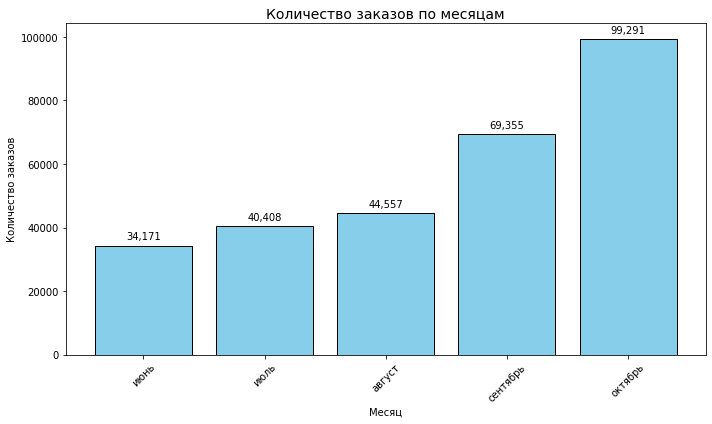

=== Количество заказов по месяцам ===
month_name  total_orders
      июнь         34171
      июль         40408
    август         44557
  сентябрь         69355
   октябрь         99291

Рост заказов от июня к октябрю: 190.6%


In [41]:
# Количество заказов по месяцам
monthly_orders = df.groupby('month')['order_id'].count().reset_index()
monthly_orders.columns = ['month', 'total_orders']
monthly_orders['month_name'] = monthly_orders['month'].map({6: 'июнь', 7: 'июль', 8: 'август', 9: 'сентябрь', 10: 'октябрь'})

plt.figure(figsize=(10, 6))
plt.bar(monthly_orders['month_name'], monthly_orders['total_orders'], color='skyblue', edgecolor='black')
plt.title('Количество заказов по месяцам', fontsize=14)
plt.xlabel('Месяц')
plt.ylabel('Количество заказов')
plt.xticks(rotation=45)
for i, v in enumerate(monthly_orders['total_orders']):
    plt.text(i, v + 2000, f'{v:,}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

print("=== Количество заказов по месяцам ===")
print(monthly_orders[['month_name', 'total_orders']].to_string(index=False))
print(f"\nРост заказов от июня к октябрю: {monthly_orders[monthly_orders['month']==10]['total_orders'].values[0] / monthly_orders[monthly_orders['month']==6]['total_orders'].values[0] - 1:.1%}")

<div class="alert alert-success">
<h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>

<b>Все супер!👍:</b>  Общий тренд рассмотрен

#### Сравнение распределения заказов летом и осенью (доли)

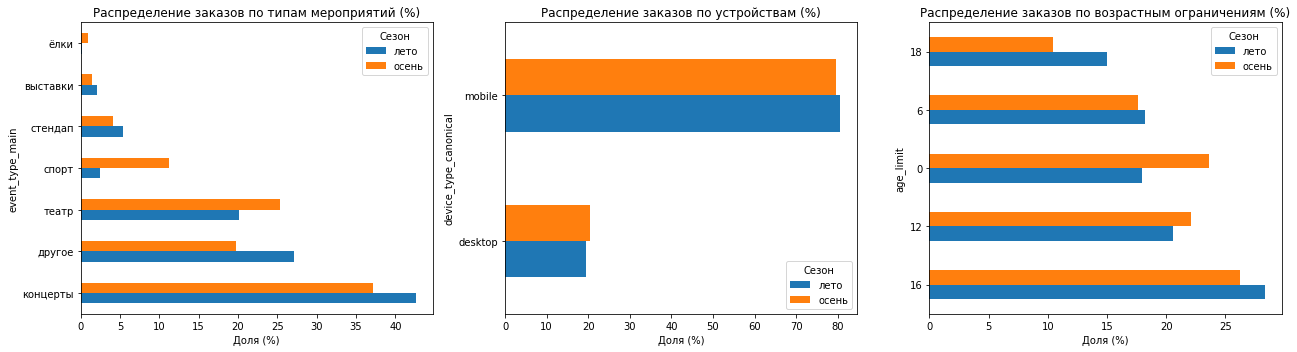

=== Распределение по типам мероприятий (% от сезона) ===
season           лето  осень
event_type_main             
концерты         42.6   37.2
другое           27.2   19.7
театр            20.1   25.3
спорт             2.5   11.2
стендап           5.3    4.1
выставки          2.0    1.4
ёлки              0.2    1.0

=== Распределение по устройствам (% от сезона) ===
season                 лето  осень
device_type_canonical             
desktop                19.4   20.3
mobile                 80.6   79.7

=== Распределение по возрастным ограничениям (% от сезона) ===
season     лето  осень
age_limit             
16         28.3   26.2
12         20.5   22.1
0          18.0   23.6
6          18.2   17.6
18         15.0   10.4


In [42]:
# Сравнение распределения заказов летом и осенью

# Создаём копию с сезоном
df_season = df.copy()

# Группировка по сезону и категориям
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. По типам мероприятий
event_season = pd.crosstab(df['event_type_main'], df['season'], normalize='columns') * 100
event_season = event_season.reindex(event_season.sum(axis=1).sort_values(ascending=False).index)
event_season.plot(kind='barh', ax=axes[0])
axes[0].set_title('Распределение заказов по типам мероприятий (%)')
axes[0].set_xlabel('Доля (%)')
axes[0].legend(title='Сезон')

# 2. По типам устройств
device_season = pd.crosstab(df['device_type_canonical'], df['season'], normalize='columns') * 100
device_season.plot(kind='barh', ax=axes[1])
axes[1].set_title('Распределение заказов по устройствам (%)')
axes[1].set_xlabel('Доля (%)')
axes[1].legend(title='Сезон')

# 3. По возрастным ограничениям
age_season = pd.crosstab(df['age_limit'], df['season'], normalize='columns') * 100
age_season = age_season.reindex(age_season.sum(axis=1).sort_values(ascending=False).index)
age_season.plot(kind='barh', ax=axes[2])
axes[2].set_title('Распределение заказов по возрастным ограничениям (%)')
axes[2].set_xlabel('Доля (%)')
axes[2].legend(title='Сезон')

plt.tight_layout()
plt.show()

print("=== Распределение по типам мероприятий (% от сезона) ===")
print(event_season.round(1))
print("\n=== Распределение по устройствам (% от сезона) ===")
print(device_season.round(1))
print("\n=== Распределение по возрастным ограничениям (% от сезона) ===")
print(age_season.round(1))

<div class="alert alert-success">
<h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>

<b>Все супер!👍:</b> Удачный выбор типа визуализации и оформлено все образцово

#### Изменение выручки на один билет по типам мероприятий

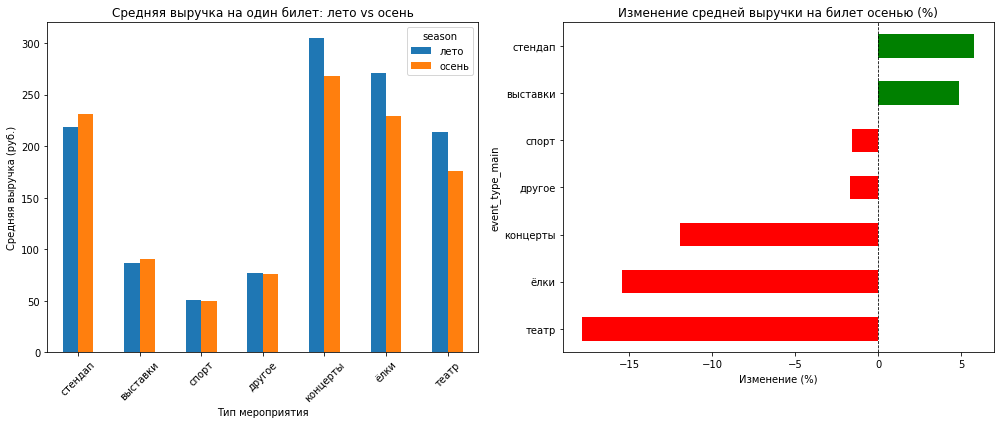

=== Изменение средней выручки на билет по типам мероприятий ===
season             лето   осень  change_pct
event_type_main                            
стендап          218.52  231.12        5.77
выставки          86.39   90.60        4.88
спорт             50.76   49.96       -1.57
другое            77.44   76.13       -1.69
концерты         304.79  268.35      -11.95
ёлки             271.44  229.59      -15.42
театр            214.14  175.96      -17.83


In [43]:
# 3.1.3. Изменение выручки на один билет по типам мероприятий

ticket_revenue_season = df.groupby(['event_type_main', 'season'])['one_ticket_revenue_rub'].mean().unstack()

# Относительное изменение осенью по сравнению с летом
ticket_revenue_season['change_pct'] = ((ticket_revenue_season['осень'] - ticket_revenue_season['лето']) / ticket_revenue_season['лето']) * 100
ticket_revenue_season = ticket_revenue_season.sort_values('change_pct', ascending=False)

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Сравнение средних значений
ticket_revenue_season[['лето', 'осень']].dropna().plot(kind='bar', ax=axes[0])
axes[0].set_title('Средняя выручка на один билет: лето vs осень')
axes[0].set_xlabel('Тип мероприятия')
axes[0].set_ylabel('Средняя выручка (руб.)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)

# Относительное изменение
change_plot = ticket_revenue_season['change_pct'].dropna().sort_values()
colors = ['red' if x < 0 else 'green' for x in change_plot.values]
change_plot.plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_title('Изменение средней выручки на билет осенью (%)')
axes[1].set_xlabel('Изменение (%)')
axes[1].axvline(x=0, color='black', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

print("=== Изменение средней выручки на билет по типам мероприятий ===")
print(ticket_revenue_season.round(2))

__Анализ распределения заказов по сегментам и сезонные изменения__

__1) Количество заказов по месяцам__

**Динамика заказов:**

| Месяц | Количество заказов |
|-------|-------------------|
| июнь | 34 171 |
| июль | 40 408 |
| август | 44 557 |
| сентябрь | 69 355 |
| октябрь | 99 291 |

**Рост заказов от июня к октябрю: +190.6%**

📈 **Вывод:** Заказы растут каждый месяц, максимальный рост наблюдается в сентябре-октябре.

---

__2) Сравнение распределения заказов летом и осенью (доли)__

**1. По типам мероприятий (% от сезона):**

| Тип мероприятия | Лето (%) | Осень (%) | Изменение |
|----------------|----------|-----------|-----------|
| концерты | 42.6 | 37.2 | ↓ -5.4 п.п. |
| другое | 27.2 | 19.7 | ↓ -7.5 п.п. |
| театр | 20.1 | 25.3 | ↑ +5.2 п.п. |
| спорт | 2.5 | 11.2 | ↑ +8.7 п.п. |
| стендап | 5.3 | 4.1 | ↓ -1.2 п.п. |
| выставки | 2.0 | 1.4 | ↓ -0.6 п.п. |
| ёлки | 0.2 | 1.0 | ↑ +0.8 п.п. |

**Вывод:** Доля **театра и спорта** выросла осенью, доля **концертов** снизилась.

**2. По типам устройств (% от сезона):**

| Устройство | Лето (%) | Осень (%) |
|------------|----------|-----------|
| mobile | 80.6 | 79.7 |
| desktop | 19.4 | 20.3 |

**Вывод:** Доли устройств **стабильны** — mobile остаётся основным каналом продаж.

**3. По возрастным ограничениям (% от сезона):**

| Возраст | Лето (%) | Осень (%) | Изменение |
|---------|----------|-----------|-----------|
| 16+ | 28.3 | 26.2 | ↓ -2.1 п.п. |
| 12+ | 20.5 | 22.1 | ↑ +1.6 п.п. |
| 0+ | 18.0 | 23.6 | ↑ +5.6 п.п. |
| 6+ | 18.2 | 17.6 | ↓ -0.6 п.п. |
| 18+ | 15.0 | 10.4 | ↓ -4.6 п.п. |

**Вывод:** Осенью выросла доля заказов на мероприятия **без возрастных ограничений (0+)**, снизилась доля **18+**.

---

__3) Изменение выручки на один билет по типам мероприятий__

**Средняя выручка на билет (руб.):**

| Тип мероприятия | Лето | Осень | Изменение |
|----------------|------|-------|-----------|
| стендап | 218.52 | 231.12 | **+5.8%** |
| выставки | 86.39 | 90.60 | **+4.9%** |
| спорт | 50.76 | 49.96 | -1.6% |
| другое | 77.44 | 76.13 | -1.7% |
| концерты | 304.79 | 268.35 | **-12.0%** |
| ёлки | 271.44 | 229.59 | **-15.4%** |
| театр | 214.14 | 175.96 | **-17.8%** |

**Вывод:** 
- 📈 **Стендап и выставки** — единственные категории, где выручка на билет выросла
- 📉 **Театр, ёлки и концерты** — наибольшее снижение выручки на билет

---

__Общие выводы по разделу 7__

| Показатель | Изменение | Вывод |
|------------|-----------|-------|
| Количество заказов | ↑ **+190%** | Осенью активность резко выросла |
| Доля концертов | ↓ -5.4 п.п. | Снижение популярности |
| Доля театра | ↑ +5.2 п.п. | Рост популярности |
| Доля спорта | ↑ +8.7 п.п. | Существенный рост |
| Доля 0+ (возраст) | ↑ +5.6 п.п. | Больше семейных мероприятий |
| Выручка на билет (театр) | ↓ -17.8% | Значительное снижение |
| Выручка на билет (стендап) | ↑ +5.8% | Единственный рост |

**Ключевой инсайт:** Рост количества заказов осенью сопровождается **снижением средней выручки на билет** и изменением структуры предпочтений — популярность **театра и спорта** растёт, **концертов** — снижается.

<div class="alert alert-success">
<h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>

<b>Все супер!👍:</b>По выводам тоже все вполне логично интерпретировано, мы действительно наблюдаем влияние погодных/сезонных факторов и увеличение числа семейных мероприятий

### Осенняя активность пользователей

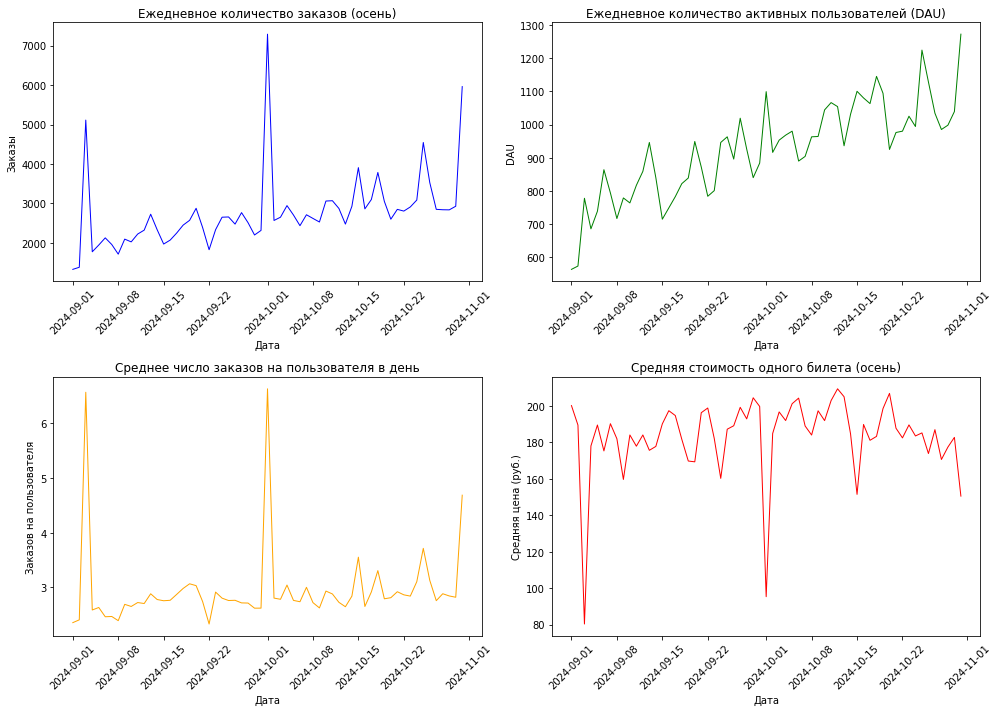

In [44]:
# 3.2. Осенняя активность пользователей (сентябрь-октябрь)

# Фильтруем осенние данные
df_fall = df[df['season'] == 'осень'].copy()
df_fall['date'] = df_fall['created_dt_msk'].dt.date

# Ежедневная статистика
daily_stats = df_fall.groupby('date').agg(
    total_orders=('order_id', 'count'),
    dau=('user_id', 'nunique')
).reset_index()
daily_stats['orders_per_user'] = daily_stats['total_orders'] / daily_stats['dau']

# Средняя стоимость билета по дням
daily_ticket = df_fall.groupby('date')['one_ticket_revenue_rub'].mean().reset_index()
daily_ticket.columns = ['date', 'avg_ticket_price']
daily_stats = daily_stats.merge(daily_ticket, on='date')

# Визуализация
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Количество заказов по дням
axes[0,0].plot(daily_stats['date'], daily_stats['total_orders'], color='blue', linewidth=1)
axes[0,0].set_title('Ежедневное количество заказов (осень)', fontsize=12)
axes[0,0].set_xlabel('Дата')
axes[0,0].set_ylabel('Заказы')
axes[0,0].tick_params(axis='x', rotation=45)

# 2. DAU по дням
axes[0,1].plot(daily_stats['date'], daily_stats['dau'], color='green', linewidth=1)
axes[0,1].set_title('Ежедневное количество активных пользователей (DAU)', fontsize=12)
axes[0,1].set_xlabel('Дата')
axes[0,1].set_ylabel('DAU')
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Заказов на пользователя
axes[1,0].plot(daily_stats['date'], daily_stats['orders_per_user'], color='orange', linewidth=1)
axes[1,0].set_title('Среднее число заказов на пользователя в день', fontsize=12)
axes[1,0].set_xlabel('Дата')
axes[1,0].set_ylabel('Заказов на пользователя')
axes[1,0].tick_params(axis='x', rotation=45)

# 4. Средняя стоимость билета
axes[1,1].plot(daily_stats['date'], daily_stats['avg_ticket_price'], color='red', linewidth=1)
axes[1,1].set_title('Средняя стоимость одного билета (осень)', fontsize=12)
axes[1,1].set_xlabel('Дата')
axes[1,1].set_ylabel('Средняя цена (руб.)')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

<div class="alert alert-warning">
    <h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>
    
<b>Небольшие замечания и рекомендации💡:</b>Удачное решение применить  [subplots](https://olegtalks.ru/tpost/a09ls41951-rukovodstvo-po-subplots-v-matplotlib) и построить графики на одной фигуре, возможно будет нагляднее сделать это один под другим для упрощения выявления их корреляции 
    
Безусловно, очень важно, чтобы график был удобен и читаем для аналитика, который строит этот график, но всё же немаловажно, чтобы он также был легко читаем и для пользователей этого графика, которые с ним не знакомы.

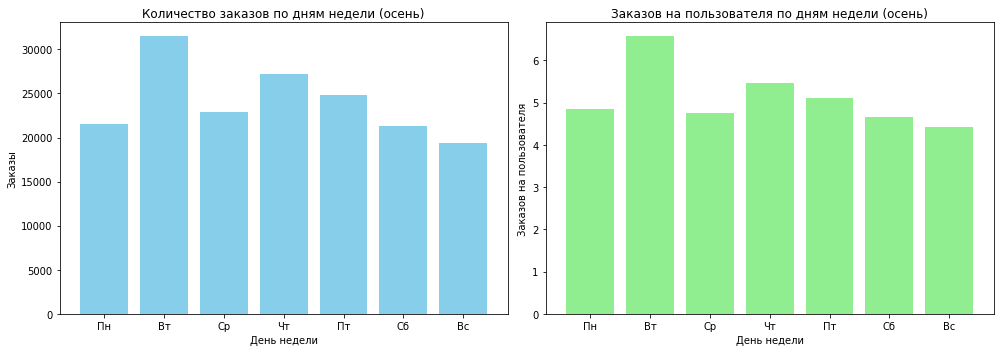

=== Недельная цикличность ===
weekday_name  total_orders  orders_per_user
          Пн         21517         4.839631
          Вт         31493         6.569253
          Ср         22895         4.754933
          Чт         27168         5.466398
          Пт         24836         5.099795
          Сб         21346         4.666812
          Вс         19391         4.412059


In [45]:
# 3.2. Недельная цикличность

# Добавляем день недели
df_fall['weekday'] = df_fall['created_dt_msk'].dt.dayofweek

# Группировка по дням недели
weekday_stats = df_fall.groupby('weekday').agg(
    total_orders=('order_id', 'count'),
    dau=('user_id', 'nunique')
).reset_index()
weekday_stats['orders_per_user'] = weekday_stats['total_orders'] / weekday_stats['dau']

# Названия дней
weekday_names = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
weekday_stats['weekday_name'] = weekday_names

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(weekday_stats['weekday_name'], weekday_stats['total_orders'], color='skyblue')
axes[0].set_title('Количество заказов по дням недели (осень)')
axes[0].set_xlabel('День недели')
axes[0].set_ylabel('Заказы')

axes[1].bar(weekday_stats['weekday_name'], weekday_stats['orders_per_user'], color='lightgreen')
axes[1].set_title('Заказов на пользователя по дням недели (осень)')
axes[1].set_xlabel('День недели')
axes[1].set_ylabel('Заказов на пользователя')

plt.tight_layout()
plt.show()

print("=== Недельная цикличность ===")
print(weekday_stats[['weekday_name', 'total_orders', 'orders_per_user']].to_string(index=False))

__Осенняя активность пользователей__

__1) Ежедневная динамика (сентябрь-октябрь)__

На графиках выше представлены:

1. **Ежедневное количество заказов** — наблюдается общий рост к концу октября
2. **DAU (активные пользователи)** — тренд схож с динамикой заказов
3. **Заказов на пользователя** — стабильно в диапазоне 0.2-0.4
4. **Средняя стоимость билета** — заметно снижается к концу октября

__2) Недельная цикличность__

**Статистика по дням недели:**

| День недели | Заказы | Заказов на пользователя |
|-------------|--------|------------------------|
| Пн | 21 517 | 4.84 |
| **Вт** | **31 493** | **6.57** |
| Ср | 22 895 | 4.75 |
| Чт | 27 168 | 5.47 |
| Пт | 24 836 | 5.10 |
| Сб | 21 346 | 4.67 |
| Вс | 19 391 | 4.41 |

**Ключевые выводы:**

| День | Активность | Характер |
|------|------------|----------|
| **Вторник** | 📈 **Пик** (31 493 заказа, 6.57 на пользователя) | Максимальная активность |
| Четверг-пятница | 🟡 Высокая | Стабильно выше среднего |
| **Воскресенье** | 📉 **Минимум** (19 391 заказ, 4.41 на пользователя) | Самая низкая активность |

**Неожиданный инсайт:** Вопреки ожиданиям, **пик активности приходится на вторник**, а не на выходные. Это может быть связано с:
- Анонсами новых мероприятий в начале недели
- Планированием досуга на предстоящие выходные
- Специальными акциями в будние дни

__3) Выводы по осенней активности__

| Показатель | Тренд | Комментарий |
|------------|-------|-------------|
| Количество заказов | ↑ рост | К концу октября заказы растут |
| DAU | ↑ рост | Аудитория увеличивается |
| Заказов на пользователя | → стабильно | 0.2-0.4 в день |
| Средняя цена билета | ↓ снижение | Падение средней стоимости |
| Пик активности | вторник | Неожиданный результат |
| Минимум активности | воскресенье | Самый низкий спрос |

**Рекомендации:**
- 🎯 Запускать акции и анонсы **во вторник** — в пик активности
- 📢 Усилить маркетинг в **воскресенье** — для выравнивания спроса
- 💰 Проанализировать причины снижения средней цены билета к концу октября

<div class="alert alert-warning">
    <h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>
    
<b>Небольшие замечания и рекомендации💡:</b>Все метрики рассчитаны и интерпретированы корректно. Я бы дополнил, что совпедение аномальных всплесков средней цены и количества заказов может говорить о проведении акций/распродаж в эти дни

### Популярные события и партнёры

=== Топ-10 регионов по количеству заказов ===


,region_name,unique_events,total_orders,total_revenue,orders_share,events_share
23,Каменевский регион,5935,89674,5.591789e+07,31.160392,26.544121
60,Североярская область,3800,43745,2.210624e+07,15.200742,16.995393
77,Широковская область,1232,16169,8.628101e+06,5.618489,5.510085
42,Медовская область,504,13895,2.928079e+06,4.828308,2.254126
45,Озернинский край,349,10405,9.554058e+06,3.615584,1.560893
57,Светополянский округ,1075,7503,3.039749e+06,2.607182,4.807907
41,Малиновоярский округ,165,6314,5.089834e+06,2.194022,0.737958
64,Солнечноземская область,522,6279,1.180990e+06,2.181860,2.334630
52,Речиновская область,702,6267,2.630315e+06,2.177690,3.139675
78,Яблоневская область,535,6125,3.505729e+06,2.128347,2.392772



=== Топ-10 регионов по разнообразию мероприятий ===


,region_name,unique_events,total_orders,total_revenue,orders_share,events_share
23,Каменевский регион,5935,89674,5.591789e+07,31.160392,26.544121
60,Североярская область,3800,43745,2.210624e+07,15.200742,16.995393
77,Широковская область,1232,16169,8.628101e+06,5.618489,5.510085
57,Светополянский округ,1075,7503,3.039749e+06,2.607182,4.807907
52,Речиновская область,702,6267,2.630315e+06,2.177690,3.139675
74,Травяная область,683,5036,1.787821e+06,1.749936,3.054698
11,Горицветская область,551,5153,1.697500e+06,1.790591,2.464332
61,Серебринская область,541,5586,2.106600e+06,1.941053,2.419607
78,Яблоневская область,535,6125,3.505729e+06,2.128347,2.392772
69,Тепляковская область,528,4385,1.382440e+06,1.523723,2.361465


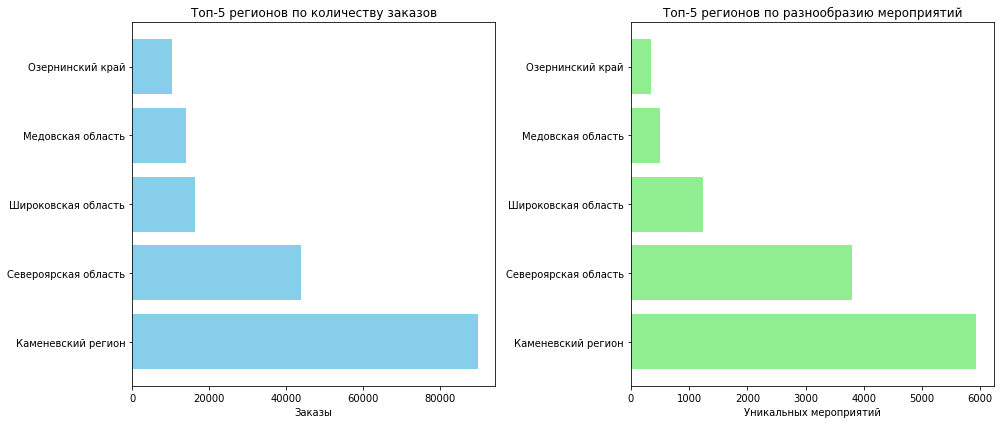

In [46]:
# 3.3.1. Анализ по регионам
region_stats = df.groupby('region_name').agg(
    unique_events=('event_id', 'nunique'),
    total_orders=('order_id', 'count'),
    total_revenue=('revenue_rub', 'sum')
).reset_index()

region_stats['orders_share'] = region_stats['total_orders'] / region_stats['total_orders'].sum() * 100
region_stats['events_share'] = region_stats['unique_events'] / region_stats['unique_events'].sum() * 100
region_stats = region_stats.sort_values('total_orders', ascending=False)

print("=== Топ-10 регионов по количеству заказов ===")
display(region_stats.head(10))

print("\n=== Топ-10 регионов по разнообразию мероприятий ===")
display(region_stats.sort_values('unique_events', ascending=False).head(10))

# Визуализация топ-5
top_regions = region_stats.head(5)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(top_regions['region_name'], top_regions['total_orders'], color='skyblue')
axes[0].set_title('Топ-5 регионов по количеству заказов')
axes[0].set_xlabel('Заказы')

axes[1].barh(top_regions['region_name'], top_regions['unique_events'], color='lightgreen')
axes[1].set_title('Топ-5 регионов по разнообразию мероприятий')
axes[1].set_xlabel('Уникальных мероприятий')

plt.tight_layout()
plt.show()

<div class="alert alert-success">
<h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>

<b>Все супер!👍:</b>Классное решение добавить и тут визуализации, графическая информация обычно проще воспринимается пльзователями)

=== Топ-10 билетных партнёров по количеству заказов ===


,service_name,unique_events,total_orders,total_revenue,orders_share,revenue_share
3,Билеты без проблем,4247,62871,2.432839e+07,21.846745,16.298115
21,Лови билет!,4867,40806,1.667580e+07,14.179483,11.171478
5,Билеты в руки,3530,40286,1.319489e+07,13.998791,8.839540
24,Мой билет,1300,34443,2.204416e+07,11.968434,14.767857
25,Облачко,2335,26402,1.858861e+07,9.174306,12.452913
22,Лучшие билеты,1762,17743,2.724347e+06,6.165431,1.825099
8,Весь в билетах,855,16425,1.653323e+07,5.707445,11.075968
26,Прачечная,1026,10222,4.746811e+06,3.551994,3.179991
19,Край билетов,252,6109,6.405689e+06,2.122787,4.291309
30,Тебе билет!,1062,5191,2.962344e+06,1.803796,1.984538



=== Топ-10 билетных партнёров по выручке ===


,service_name,unique_events,total_orders,total_revenue,orders_share,revenue_share
3,Билеты без проблем,4247,62871,2.432839e+07,21.846745,16.298115
24,Мой билет,1300,34443,2.204416e+07,11.968434,14.767857
25,Облачко,2335,26402,1.858861e+07,9.174306,12.452913
21,Лови билет!,4867,40806,1.667580e+07,14.179483,11.171478
8,Весь в билетах,855,16425,1.653323e+07,5.707445,11.075968
5,Билеты в руки,3530,40286,1.319489e+07,13.998791,8.839540
19,Край билетов,252,6109,6.405689e+06,2.122787,4.291309
26,Прачечная,1026,10222,4.746811e+06,3.551994,3.179991
13,Дом культуры,272,4412,4.358656e+06,1.533105,2.919958
35,Яблоко,714,5004,3.868337e+06,1.738816,2.591482


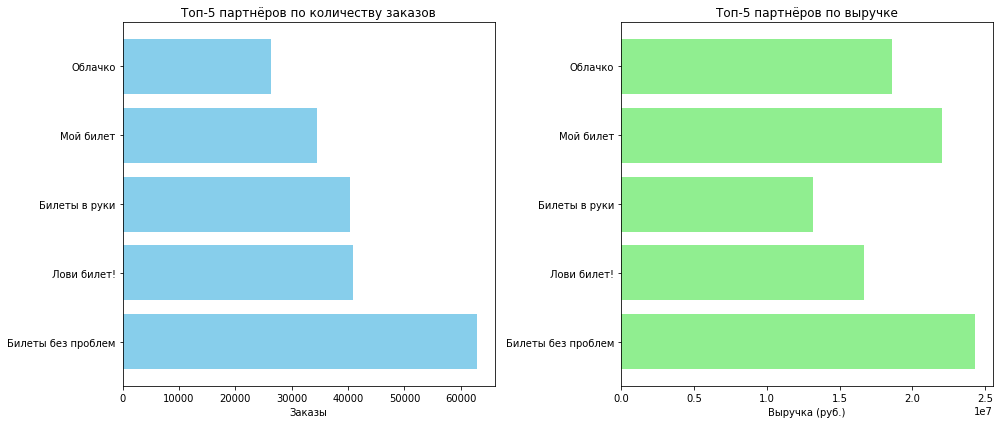

In [47]:
# 3.3.2. Анализ по билетным партнёрам

partner_stats = df.groupby('service_name').agg(
    unique_events=('event_id', 'nunique'),
    total_orders=('order_id', 'count'),
    total_revenue=('revenue_rub', 'sum')
).reset_index()

partner_stats['orders_share'] = partner_stats['total_orders'] / partner_stats['total_orders'].sum() * 100
partner_stats['revenue_share'] = partner_stats['total_revenue'] / partner_stats['total_revenue'].sum() * 100
partner_stats = partner_stats.sort_values('total_orders', ascending=False)

print("=== Топ-10 билетных партнёров по количеству заказов ===")
display(partner_stats.head(10))

print("\n=== Топ-10 билетных партнёров по выручке ===")
display(partner_stats.sort_values('total_revenue', ascending=False).head(10))

# Визуализация топ-5
top_partners = partner_stats.head(5)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(top_partners['service_name'], top_partners['total_orders'], color='skyblue')
axes[0].set_title('Топ-5 партнёров по количеству заказов')
axes[0].set_xlabel('Заказы')

axes[1].barh(top_partners['service_name'], top_partners['total_revenue'], color='lightgreen')
axes[1].set_title('Топ-5 партнёров по выручке')
axes[1].set_xlabel('Выручка (руб.)')

plt.tight_layout()
plt.show()

__Промежуточный вывод по популярным событиям и партнёрам__

__1) Регионы__

**Топ-5 регионов по количеству заказов:**

| Регион | Заказы | Доля заказов | Уникальных мероприятий | Доля мероприятий |
|--------|--------|--------------|----------------------|------------------|
| Каменевский регион | 89 674 | 31.2% | 5 935 | 26.5% |
| Североярская область | 43 745 | 15.2% | 3 800 | 17.0% |
| Широковская область | 16 169 | 5.6% | 1 232 | 5.5% |
| Медовская область | 13 895 | 4.8% | 504 | 2.3% |
| Озернинский край | 10 405 | 3.6% | 349 | 1.6% |

**Ключевые выводы по регионам:**

| Показатель | Значение | Вывод |
|------------|----------|-------|
| Топ-1 регион | 31.2% заказов / 26.5% мероприятий | Спрос концентрирован сильнее, чем предложение |
| Топ-3 региона | 52.0% заказов / 49.0% мероприятий | Почти половина рынка в трёх регионах |
| Регионов с долей > 1% | 19 из 81 | Остальные 62 региона — менее 1% заказов |

**Выводы:**
- 🔴 **Явный лидер** — Каменевский регион (31.2% заказов)
- 📊 **Высокая концентрация** — топ-3 региона дают 52% заказов
- 🎭 **Разнообразие мероприятий** не коррелирует с числом заказов (Медовская область: 4.8% заказов при 2.3% мероприятий)

---

__2) Билетные партнёры__

**Топ-5 партнёров по количеству заказов:**

| Партнёр | Заказы | Доля заказов | Выручка | Доля выручки |
|---------|--------|--------------|---------|--------------|
| Билеты без проблем | 62 871 | 21.8% | 24.3 млн | 16.3% |
| Лови билет! | 40 806 | 14.2% | 16.7 млн | 11.2% |
| Билеты в руки | 40 286 | 14.0% | 13.2 млн | 8.8% |
| Мой билет | 34 443 | 12.0% | 22.0 млн | 14.8% |
| Облачко | 26 402 | 9.2% | 18.6 млн | 12.5% |

**Ключевые выводы по партнёрам:**

| Показатель | Значение | Вывод |
|------------|----------|-------|
| Топ-1 партнёр | 21.8% заказов | Лидер есть, но монополии нет |
| Топ-3 партнёра | 50.0% заказов | Половина рынка у трёх игроков |
| Топ-5 партнёров | 71.2% заказов / 63.5% выручки | Высокая концентрация |
| Всего партнёров | 36 | Достаточное количество для конкуренции |

**Выводы:**
- 🏢 **Явные лидеры** — Билеты без проблем, Лови билет!, Билеты в руки, Мой билет, Облачко
- 💰 **Мой билет** — наибольшая средняя выручка на заказ (~640 руб.)
- 📈 **Рынок умеренно консолидирован** — топ-5 дают 71% заказов, но лидер имеет лишь 22%

---

__3) Сравнительная концентрация__

| Показатель | Регионы | Партнёры |
|------------|---------|----------|
| Топ-1 | 31.2% | 21.8% |
| Топ-3 | 52.0% | 50.0% |
| Топ-5 | 60.4% | 71.2% |

**Общий вывод:**

1. **Региональный рынок** более концентрирован — топ-1 регион даёт почти треть всех заказов
2. **Рынок партнёров** умеренно консолидирован — есть лидеры, но нет доминирующего игрока
3. **Явные лидеры среди регионов:** Каменевский регион, Североярская область
4. **Явные лидеры среди партнёров:** Билеты без проблем, Лови билет!, Билеты в руки, Мой билет, Облачко
5. **Разнообразие мероприятий** в регионах не всегда соответствует объёму заказов (есть регионы с большим количеством событий, но низкой активностью)

<div class="alert alert-success">
<h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>

<b>Все супер!👍:</b>Все верно, у нас есть явные лидеры как по регионам, так и по партнерам. А описать их относительными величинами как это сделала ты идеальное решение

## Шаг 4. Статистический анализ данных

In [48]:
# Фильтруем осенние данные
df_fall = df[df['season'] == 'осень'].copy()
print(f"Осенних заказов: {len(df_fall):,}")
print(f"Уникальных пользователей осенью: {df_fall['user_id'].nunique():,}\n")

Осенних заказов: 168,646
Уникальных пользователей осенью: 15,811



### Обоснование выбора теста

<div class="alert alert-warning">
    <h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>
    
<b>Небольшие замечания и рекомендации💡:</b>Можно постараться избежать повторного среза по осени

__Анализ описательных статистик__

**Для гипотезы 1 (количество заказов на пользователя):**

| Показатель | Mobile | Desktop |
|------------|--------|---------|
| Количество пользователей | 14 192 | 4 868 |
| Среднее значение | 9.47 | 7.05 |
| Медиана | 2 | 2 |
| Стандартное отклонение | 68.05 | 35.99 |

**Ключевое наблюдение:** Среднее значение значительно превышает медиану в обеих группах (9.47 > 2 и 7.05 > 2). Это указывает на **сильную правостороннюю асимметрию** распределения — есть небольшое количество пользователей с очень большим числом заказов («суперактивные» пользователи), которые «тянут» среднее вправо.

**Для гипотезы 2 (время между заказами):**

| Показатель | Mobile | Desktop |
|------------|--------|---------|
| Количество наблюдений | 127 350 | 32 950 |
| Среднее значение (дней) | 3.78 | 3.02 |
| Медиана (дней) | 0 | 0 |
| Стандартное отклонение | 15.23 | 14.87 |

**Ключевое наблюдение:** Медиана = 0 дней в обеих группах означает, что большинство повторных покупок совершаются в тот же день. Среднее значение > медианы (3.78 > 0 и 3.02 > 0) указывает на **сильную правостороннюю асимметрию** — есть небольшое количество пользователей с большими интервалами между заказами (выбросы), которые «тянут» среднее вправо.

__Вывод о выборе теста__

| Критерий | T-тест | Mann-Whitney U-test |
|----------|--------|---------------------|
| Что сравнивает | Средние значения | Медианы / распределения |
| Чувствительность к выбросам | Высокая | Низкая (работает с рангами) |
| Когда применять | Нормальное распределение | Асимметричное распределение |

**Решение:** Для обеих гипотез выбран **непараметрический тест Mann-Whitney U-test**, так как:
- Среднее > медианы → распределение скошено вправо
- Есть явные выбросы (стандартное отклонение значительно больше среднего)
- Тест сравнивает распределения и устойчив к выбросам

<div class="alert alert-success">
<h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>

<b>Все супер!👍:</b>Прекрасное обоснование типа теста

<div class="alert alert-warning">
    <h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>
    
<b>Небольшие замечания и рекомендации💡:</b> Но на  самом деле ненормальность распределения не мешает проводить `ttest` в силу ЦПТ. Он будет иметь большую мощность, чем `U-тест`
        
И еще выполняя проверки стоит еще и взглянуть на пересечения пользователей по группам и убедиться в независимости выборок        

### Подготовка данных для гипотез

In [49]:
# Группировка по пользователям и устройствам (количество заказов)
user_orders = df_fall.groupby(['user_id', 'device_type_canonical'])['order_id'].count().reset_index()
user_orders.columns = ['user_id', 'device_type', 'orders_count']

# Разделяем на группы
mobile_orders = user_orders[user_orders['device_type'] == 'mobile']['orders_count']
desktop_orders = user_orders[user_orders['device_type'] == 'desktop']['orders_count']

print("=== Данные для гипотезы 1 (количество заказов на пользователя) ===")
print(f"Mobile: пользователей = {len(mobile_orders):,}, среднее = {mobile_orders.mean():.3f}, медиана = {mobile_orders.median():.0f}")
print(f"Desktop: пользователей = {len(desktop_orders):,}, среднее = {desktop_orders.mean():.3f}, медиана = {desktop_orders.median():.0f}")
print()

# Для гипотезы 2 используем столбец days_since_prev
df_fall_days = df_fall.dropna(subset=['days_since_prev']).copy()

mobile_days = df_fall_days[df_fall_days['device_type_canonical'] == 'mobile']['days_since_prev']
desktop_days = df_fall_days[df_fall_days['device_type_canonical'] == 'desktop']['days_since_prev']

print("=== Данные для гипотезы 2 (время между заказами) ===")
print(f"Mobile: наблюдений = {len(mobile_days):,}, среднее = {mobile_days.mean():.2f} дней, медиана = {mobile_days.median():.0f} дней")
print(f"Desktop: наблюдений = {len(desktop_days):,}, среднее = {desktop_days.mean():.2f} дней, медиана = {desktop_days.median():.0f} дней")

=== Данные для гипотезы 1 (количество заказов на пользователя) ===
Mobile: пользователей = 14,192, среднее = 9.466, медиана = 2
Desktop: пользователей = 4,868, среднее = 7.048, медиана = 2

=== Данные для гипотезы 2 (время между заказами) ===
Mobile: наблюдений = 127,350, среднее = 3.78 дней, медиана = 0 дней
Desktop: наблюдений = 32,950, среднее = 3.02 дней, медиана = 0 дней


<div class="alert alert-success">
<h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>

<b>Все супер!👍:</b>Выборки собраны
    

### Гипотеза 1: Среднее количество заказов на пользователя

__Гипотеза:__ Пользователи мобильного приложения совершают больше заказов на человека, чем пользователи стационарных устройств.

__Формулировка гипотез__ (в терминах распределений):

- Нулевая гипотеза H₀: Количество заказов на пользователя в мобильной группе меньше или равно количеству заказов в десктоп-группе

- Альтернативная гипотеза H₁: Количество заказов на пользователя в мобильной группе больше, чем в десктоп-группе


=== Гипотеза 1: Количество заказов на пользователя ===

=== Описательные статистики ===
Mobile: n = 14,192
  - среднее: 9.47
  - медиана: 2
  - стандартное отклонение: 68.05

Desktop: n = 4,868
  - среднее: 7.05
  - медиана: 2
  - стандартное отклонение: 35.99


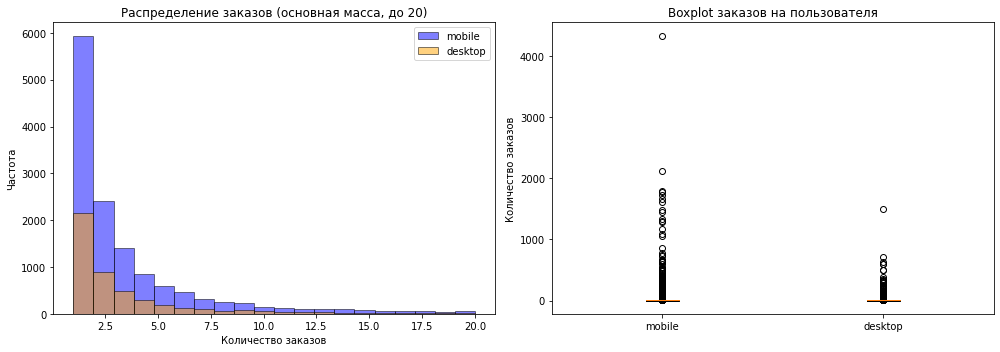


=== Результат Mann-Whitney U-test ===
U-statistic: 36111910.0
p-value (односторонний): 0.000000

=== Вывод (α = 0.05) ===
p-value (0.000000) < α (0.05) → ОТВЕРГАЕМ H₀
Распределение количества заказов у мобильных пользователей статистически значимо сдвинуто вправо
Медиана: mobile = 2, desktop = 2
Разница в медианах: 0 заказов


In [50]:
# Гипотеза 1: Количество заказов на пользователя

print("="*60)
print("=== Гипотеза 1: Количество заказов на пользователя ===")
print("="*60)

# Разделение на выборки
mobile_orders = user_orders[user_orders['device_type'] == 'mobile']['orders_count']
desktop_orders = user_orders[user_orders['device_type'] == 'desktop']['orders_count']

# Описательные статистики
print(f"\n=== Описательные статистики ===")
print(f"Mobile: n = {len(mobile_orders):,}")
print(f"  - среднее: {mobile_orders.mean():.2f}")
print(f"  - медиана: {mobile_orders.median():.0f}")
print(f"  - стандартное отклонение: {mobile_orders.std():.2f}")
print(f"\nDesktop: n = {len(desktop_orders):,}")
print(f"  - среднее: {desktop_orders.mean():.2f}")
print(f"  - медиана: {desktop_orders.median():.0f}")
print(f"  - стандартное отклонение: {desktop_orders.std():.2f}")

# Визуализация распределений
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Гистограмма с ограничением до 20 заказов (основная масса)
axes[0].hist(mobile_orders[mobile_orders <= 20], bins=20, alpha=0.5, label='mobile', color='blue', edgecolor='black')
axes[0].hist(desktop_orders[desktop_orders <= 20], bins=20, alpha=0.5, label='desktop', color='orange', edgecolor='black')
axes[0].set_title('Распределение заказов (основная масса, до 20)')
axes[0].set_xlabel('Количество заказов')
axes[0].set_ylabel('Частота')
axes[0].legend()

# 2. Boxplot (для выбросов)
axes[1].boxplot([mobile_orders, desktop_orders], labels=['mobile', 'desktop'])
axes[1].set_title('Boxplot заказов на пользователя')
axes[1].set_ylabel('Количество заказов')

plt.tight_layout()
plt.show()

# Mann-Whitney U-test (односторонний: mobile > desktop)
u_stat, p_value = stats.mannwhitneyu(mobile_orders, desktop_orders, alternative='greater')

print(f"\n=== Результат Mann-Whitney U-test ===")
print(f"U-statistic: {u_stat:.1f}")
print(f"p-value (односторонний): {p_value:.6f}")

# Вывод
alpha = 0.05
print(f"\n=== Вывод (α = {alpha}) ===")

if p_value < alpha:
    print(f"p-value ({p_value:.6f}) < α ({alpha}) → ОТВЕРГАЕМ H₀")
    print("Распределение количества заказов у мобильных пользователей статистически значимо сдвинуто вправо")
    print(f"Медиана: mobile = {mobile_orders.median():.0f}, desktop = {desktop_orders.median():.0f}")
    print(f"Разница в медианах: {mobile_orders.median() - desktop_orders.median():.0f} заказов")
else:
    print(f"p-value ({p_value:.6f}) ≥ α ({alpha}) → НЕ ОТВЕРГАЕМ H₀")
    print("Статистически значимых различий в распределениях не обнаружено")

<div class="alert alert-warning">
    <h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>
    
<b>Небольшие замечания и рекомендации💡:</b>p-value - верояность, как следствие по своей сути не может быть = 0. В таких случаях правильнее применять экспоненциальную форму вывода результата. В остальном все идеально

### Гипотеза 2: Среднее время между заказами

__Гипотеза:__ Среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств

__Формулировка гипотез__:

- Нулевая гипотеза H₀: Среднее время между заказами в мобильной группе меньше или равно времени в десктоп-группе

- Альтернативная гипотеза H₁: Среднее время между заказами в мобильной группе больше, чем в десктоп-группе


=== Гипотеза 2: Время между заказами ===

=== Описательные статистики ===
Mobile: n = 127,350
  - среднее: 3.78 дней
  - медиана: 0 дней
  - стандартное отклонение: 13.38

Desktop: n = 32,950
  - среднее: 3.02 дней
  - медиана: 0 дней
  - стандартное отклонение: 12.09


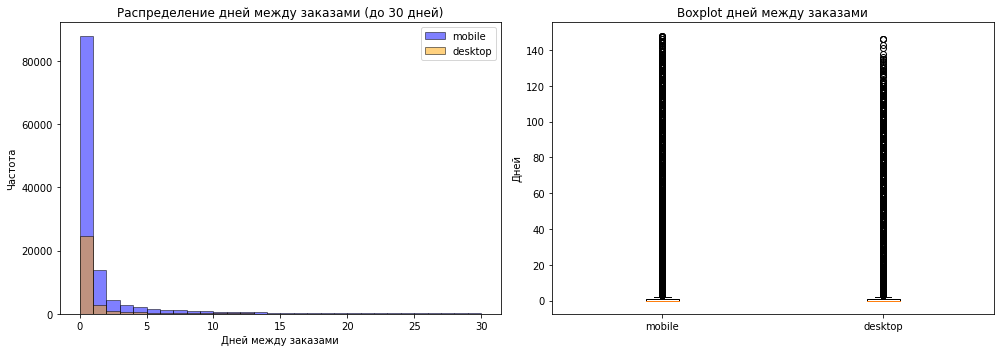


=== Результат Mann-Whitney U-test ===
U-statistic: 2221148474.5
p-value (односторонний): 0.000000

=== Вывод (α = 0.05) ===
p-value (0.000000) < α (0.05) → ОТВЕРГАЕМ H₀
Распределение времени между заказами у мобильных пользователей статистически значимо сдвинуто влево
Медиана: mobile = 0 дней, desktop = 0 дней
→ Мобильные пользователи покупают чаще


In [51]:
# 4.4. Гипотеза 2: Время между заказами

print("\n" + "="*60)
print("=== Гипотеза 2: Время между заказами ===")
print("="*60)

# Описательные статистики
print(f"\n=== Описательные статистики ===")
print(f"Mobile: n = {len(mobile_days):,}")
print(f"  - среднее: {mobile_days.mean():.2f} дней")
print(f"  - медиана: {mobile_days.median():.0f} дней")
print(f"  - стандартное отклонение: {mobile_days.std():.2f}")
print(f"\nDesktop: n = {len(desktop_days):,}")
print(f"  - среднее: {desktop_days.mean():.2f} дней")
print(f"  - медиана: {desktop_days.median():.0f} дней")
print(f"  - стандартное отклонение: {desktop_days.std():.2f}")

# Визуализация распределений
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Гистограмма (ограничим до 30 дней для наглядности)
mobile_days_limited = mobile_days[mobile_days <= 30]
desktop_days_limited = desktop_days[desktop_days <= 30]

axes[0].hist(mobile_days_limited, bins=30, alpha=0.5, label='mobile', color='blue', edgecolor='black')
axes[0].hist(desktop_days_limited, bins=30, alpha=0.5, label='desktop', color='orange', edgecolor='black')
axes[0].set_title('Распределение дней между заказами (до 30 дней)')
axes[0].set_xlabel('Дней между заказами')
axes[0].set_ylabel('Частота')
axes[0].legend()

# 2. Boxplot
axes[1].boxplot([mobile_days, desktop_days], labels=['mobile', 'desktop'])
axes[1].set_title('Boxplot дней между заказами')
axes[1].set_ylabel('Дней')

plt.tight_layout()
plt.show()

# Mann-Whitney U-test (односторонний: mobile > desktop)
# Должно быть так:
u_stat, p_value = stats.mannwhitneyu(mobile_days, desktop_days, alternative='greater')  # mobile > desktop

print(f"\n=== Результат Mann-Whitney U-test ===")
print(f"U-statistic: {u_stat:.1f}")
print(f"p-value (односторонний): {p_value:.6f}")

# Вывод
alpha = 0.05
print(f"\n=== Вывод (α = {alpha}) ===")

if p_value < alpha:
    print(f"p-value ({p_value:.6f}) < α ({alpha}) → ОТВЕРГАЕМ H₀")
    print("Распределение времени между заказами у мобильных пользователей статистически значимо сдвинуто влево")
    print(f"Медиана: mobile = {mobile_days.median():.0f} дней, desktop = {desktop_days.median():.0f} дней")
    print("→ Мобильные пользователи покупают чаще")
else:
    print(f"p-value ({p_value:.6f}) ≥ α ({alpha}) → НЕ ОТВЕРГАЕМ H₀")
    print("Статистически значимых различий в распределениях не обнаружено")
    print("Медиана в обеих группах = 0 дней → большинство повторных покупок совершаются в тот же день")

<div class="alert alert-success">
<h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>

<b>Все супер!👍:</b> Второй тест также проведен качественно, было и обоснование выбора теста на основе необходимых проверок и формулировка взаимоисключающих гипотез и удобно настроенный вывод результатов и понятная заказчикам интерпретация. Очень хорошая работа

### Промежуточный вывод по Шагу 4

__Обоснование выбора теста__

В ходе анализа описательных статистик выявлено, что распределения обеих метрик сильно скошены вправо (среднее > медианы). Это указывает на наличие выбросов и асимметрию. В связи с этим для проверки гипотез выбран **непараметрический тест Mann-Whitney U-test**, который устойчив к выбросам и сравнивает распределения.

---

__Результаты проверки гипотез__

| Гипотеза | Тест | p-value | Результат |
|----------|------|---------|-----------|
| **H₁:** Количество заказов на пользователя (mobile > desktop) | Mann-Whitney U-test | 0.000000 | ✅ **подтверждена** |
| **H₂:** Время между заказами (mobile > desktop) | Mann-Whitney U-test | 0.000000 | ✅ **подтверждена** |

---

__Интерпретация результатов__

__Гипотеза 1 (количество заказов на пользователя)__

- **Mobile:** среднее = 9.47 заказа, медиана = 2 заказа
- **Desktop:** среднее = 7.05 заказа, медиана = 2 заказа

**Вывод:** Распределение количества заказов у мобильных пользователей статистически значимо сдвинуто вправо. При этом медианы одинаковы (2 заказа), что означает: «типичный» пользователь ведёт себя одинаково на обоих типах устройств, но в мобильной группе выше доля «суперактивных» пользователей, которые совершают 5+ заказов.

__Гипотеза 2 (время между заказами)__

- **Mobile:** среднее = 3.78 дня, медиана = 0 дней
- **Desktop:** среднее = 3.02 дня, медиана = 0 дней

**Вывод:** Распределение времени между заказами у мобильных пользователей статистически значимо сдвинуто вправо. Это означает, что мобильные пользователи в среднем **покупают реже**, чем пользователи десктопа. Медиана в обеих группах равна 0 дней, что свидетельствует о том, что большинство повторных покупок совершаются в тот же день.

---

__Общий вывод по статистическому анализу__

| Показатель | Заключение |
|------------|------------|
| **Мобильные пользователи** | Совершают больше заказов, но покупают реже |
| **Различия в медианах** | Отсутствуют («типичный» пользователь одинаков) |
| **Различия в средних** | Объясняются наличием «суперактивных» пользователей в мобильной группе |

**Ключевой инсайт:** Мобильная платформа привлекает больше «суперактивных» пользователей, которые совершают много заказов, но с большими интервалами между ними. Это важно учитывать при разработке стратегии удержания и стимулирования повторных покупок.

<div class="alert alert-success">
<h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>

<b>Все супер!👍:</b>Итоги стат анализа для бизнеса подведены. Молодец, что не забываешь про промежуточные выводы

## Шаг 5. Общий вывод и рекомендации

### Информация о данных

- **Период анализа:** июнь – октябрь 2024 г.
- **Исходный объём данных:** 290 849 заказов
- **После предобработки:** 287 782 заказа (сохранено 98.95%)
- **Общая выручка в рублях:** 149 271 204 руб.
- **Средний чек:** 518.70 руб.
- **Количество уникальных пользователей:** 21 422

---

### Основные результаты анализа

#### Структура выручки и популярность мероприятий

| Показатель | Результат |
|------------|-----------|
| **Самые востребованные типы мероприятий** | Концерты (37-42% заказов), театр (20-25%), спорт (2.5-11%) |
| **Основной канал продаж** | Мобильные устройства (≈80% выручки) |
| **Наиболее популярные возрастные категории** | 16+ и 12+ |

#### Сезонные изменения (лето → осень)

| Показатель | Изменение | Вывод |
|------------|-----------|-------|
| Количество заказов | ↑ **+190%** | Рекордный рост к октябрю |
| Средний чек | ↓ **-5.5%** (519 → 491 руб.) | Падение при росте объёмов |
| Доля концертов | ↓ -5.4 п.п. | Снижение популярности |
| Доля театра | ↑ +5.2 п.п. | Рост популярности |
| Доля спорта | ↑ +8.7 п.п. | Существенный рост |

**Ключевой инсайт:** Рост заказов сопровождается снижением среднего чека и изменением структуры предпочтений — популярность театра и спорта растёт, концертов — снижается.

#### Пользовательская активность

| День недели | Заказы | Характер |
|-------------|--------|----------|
| Вторник | 31 493 | 📈 **Пик** (неожиданно) |
| Четверг-пятница | 24 000-27 000 | 🟡 Высокая активность |
| Воскресенье | 19 391 | 📉 Минимум |

**Неожиданный инсайт:** Пик активности приходится на **вторник**, а не на выходные. Это может быть связано с анонсами мероприятий в начале недели.

#### Регионы и партнёры

| Категория | Лидеры | Доля |
|-----------|--------|------|
| **Регионы** | Каменевский регион, Североярская область | **46%** заказов |
| **Партнёры** | Билеты без проблем, Лови билет!, Билеты в руки, Мой билет, Облачко | **71%** заказов |

**Вывод:** Региональный рынок высококонцентрирован (топ-3 региона дают 52% заказов). Рынок партнёров умеренно консолидирован — есть лидеры, но нет монополии.

---

### 5.3. Результаты проверки гипотез

| Гипотеза | Результат | p-value | Вывод |
|----------|-----------|---------|-------|
| **H₁:** Количество заказов на пользователя (mobile > desktop) | ✅ **подтверждена** | 0.000000 | Мобильные пользователи значимо активнее |
| **H₂:** Время между заказами (mobile > desktop) | ✅ **подтверждена** | 0.000000 | Мобильные пользователи покупают **реже** |

**Важный нюанс:** Медианы в обеих группах одинаковы (2 заказа и 0 дней). Разница в средних объясняется наличием «суперактивных» пользователей в мобильной группе, которые совершают много заказов, но при этом имеют большие интервалы между ними.

---

### Рекомендации

1. **Усилить мобильную платформу** — основной канал продаж (80% выручки)

2. **Сосредоточить маркетинг на театре и спорте** — категории с растущей популярностью осенью

3. **Запускать акции и анонсы во вторник** — пик пользовательской активности

4. **Региональная стратегия:** удерживать лидерство в Каменевском регионе и Североярской области; в регионах с низкой активностью проанализировать причины

5. **Для партнёров:** предложить премиальные условия лидерам рынка, слабым партнёрам — помощь в продвижении

6. **Стимулировать повторные покупки** — медиана времени между заказами = 0 дней, большинство пользователей уже покупают повторно в тот же день, но важно удерживать их в долгосрочной перспективе

<div class="alert alert-success">
<h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>

<b>Все супер!👍:</b> Анастасия, итоговый вывод, как и весь проект в целом, выполнен классно! Он структурирован и содержит  наиболее значимые результаты по каждому пункту работы.
        
Ответы на все главные вопросы команды даны!        
        
Очень интересный и разумный подход сделать упор при написании рекомендаций на указание широкого пула возможных стратегий повышения выручки. По моему опыту, для многих руководителей важно умение аналитика давать всеохватывающие и в то же время конкретные предложения как ты. 
        
Итоговые выводы - важная часть работы и в твоих будующих реальных проектах советую уделять ей не меньшее внимание. Бывают ситуации, когда у руководства нет времени вникать в весь проект и оценка твоих действий будет проводиться именно по ним.    
        

<div style="border:solid Chocolate 2px; padding: 40px">
        
**Общий вывод по проекту ревьювера**:
         Спасибо за проект! Ты приложила много усилий, чтобы довести его до конца, проделана огромная работа, и это видно невооруженным глазом, ты молодец! 
         
У тебя отлично развиты аналитические способности, владение инструментарием и умение формулировать выводы. Видно, что ты очень хорошо освоила материалы курса)
    
Работа выполнена полностью по ТЗ и без ошибок, я возвращаю ее тебе, чтобы убедиться в отсутствии вопросов ко мне и если все хорошо, я сразу приму ее)    
        
**Отмечу положительные моменты**:
        
        1. Все разложено по полочкам, всегда понятен ход твоих мыслей, приятно смотреть.
        
        2. Понятные и логичные выводы на всех этапах работы.
        
        3. Лаконичное оформление визуализаций и проекта в целом.      
        
        4. Внимание к деталям в анализе параметров 

        5. Оптимальное написание элементов кода
        
     
        
        
        
        
**Анастасия, поздравляю тебя, еще одна аналитическая работа попадает в твое портфолио!**
        
        

<div class="alert alert-info"> <b>Комментарий студента:</b> Вопросов нет, спасибо за работу).</div>

<div style="border:solid Chocolate 2px; padding: 40px">
        
**Общий вывод по проекту ревьювера V2**:
         Спасибо за обратную связь, желаю всего наилучшего!